# Trabalho de Séries Temporais — Grupo 5
## Modelagem comparativa da base Jena Climate com variáveis externas

**Modelo de especialização do grupo:** PLS Regression (*Partial Least Squares Regression*)  
**Base analisada neste notebook:** `jena_climate_2009_2016.csv` — arquivo congelado anexado à atividade.

> **Escopo da entrega.** O enunciado prevê cinco bases comuns para a turma. A base meteorológica Jena Climate completa está incluída neste pacote e os quatro modelos são executados sobre ela. As outras quatro bases previstas no enunciado não estão disponíveis neste pacote; por isso não são inventados resultados para elas. A estrutura de carregamento, preparação, avaliação e exportação pode ser reaplicada às demais bases quando seus arquivos forem disponibilizados.

## Protocolo fixado pelo grupo

| Item | Decisão |
|---|---|
| Granularidade final | **Horária**; a fonte de 10 em 10 minutos é agregada por hora |
| Regra principal de agregação | Média das observações da hora |
| Direção do vento | Média circular, para não produzir erro artificial no limite 0°/360° |
| Velocidade máxima do vento | Máximo dentro da hora |
| Variável-alvo | `T (degC)` — temperatura do ar, em °C |
| Horizonte | 1 passo horário = previsão da próxima hora |
| Treino–teste | **80% / 20%**, corte temporal, sem embaralhamento |
| `random_state` | **42**, em todos os componentes estocásticos |
| Sazonalidade principal | 24 observações horárias, correspondente ao ciclo diário |
| Validação final | Walk-forward, com as mesmas origens para os quatro modelos |
| Métrica principal | MAE (*Mean Absolute Error*) fora da amostra |

## Modelos comparados

1. **SARIMAX** com variáveis meteorológicas defasadas e calendário implícito na frequência horária;
2. **Holt–Winters**, utilizado como referência univariada, conforme o PDF;
3. **Random Forest Regressor**, com as features tabulares causais;
4. **PLS Regression**, modelo exclusivo do Grupo 5, usando as mesmas features tabulares do Random Forest.

O notebook também realiza STL, diagnóstico de qualidade, engenharia de atributos, busca temporal de hiperparâmetros, análise de resíduos, ACF, teste de Ljung–Box, importância de features e exportação dos resultados.


## 1. Decisões metodológicas e prevenção de vazamento

A série é originalmente observada a cada dez minutos. A conversão para uma observação por hora é feita **antes** da modelagem, usando somente as observações pertencentes àquela hora. Bins incompletos são descartados em vez de preenchidos artificialmente.

Para a previsão de `T[t+1]` na origem `t`:

- `T[t]` e demais condições meteorológicas disponíveis até `t` podem ser usadas;
- lags do alvo e das variáveis externas são calculados apenas com o histórico;
- médias e desvios móveis são calculados sobre dados até `t`, sem `bfill`;
- calendário do instante futuro é permitido, pois hora, dia da semana e dia do ano são conhecidos antecipadamente;
- valores meteorológicos **observados no futuro** não são usados como se fossem conhecidos;
- no SARIMAX, as exógenas são deslocadas uma hora: o modelo usa `X[t-1]` para explicar `T[t]` e recebe `X[t]` ao prever `T[t+1]`;
- a seleção de hiperparâmetros ocorre somente no bloco de desenvolvimento, antes do teste final.

O código mantém a série temporal ordenada. Portanto, o percentual 80/20 é temporal e não uma divisão aleatória.


In [2]:
# 2. Bibliotecas, configuração e localização da base
from pathlib import Path
from collections import deque
import json
import hashlib
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from scipy.stats import loguniform
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import ParameterSampler, TimeSeriesSplit
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

RANDOM_STATE = 42
TRAIN_FRACTION = 0.80
TEST_FRACTION = 0.20
FREQ = '1h'
HORIZON = 1
SEASONAL_PERIOD = 24
REFIT_EVERY = 168                 # reajuste semanal para modelos tabulares
MAX_TRAIN_ROWS = 4_380            # janela móvel de aproximadamente seis meses
SEARCH_MAX_ROWS = 4_380           # janela temporal usada na seleção tabular
SARIMAX_MAX_TRAIN_ROWS = 720      # janela de aproximadamente 30 dias
N_JOBS = -1

DATE_COL = 'Date Time'
TARGET = 'T (degC)'

# --- Caminhos ---------------------------------------------------------------
# Estrutura do projeto:
#   <raiz>/notebooks/grupo4/trabalho_grupo5_pls_jena_horario.ipynb   <- notebook (cwd)
#   <raiz>/notebooks/grupo4/resultados_grupo5_jena_horario/          <- saídas
#   <raiz>/bases/grupo4/jena_climate_2009_2016.csv                   <- base
PACKAGE_DIR = Path.cwd()                      # notebooks/grupo4
PROJECT_ROOT = PACKAGE_DIR.parents[1]         # raiz do projeto (sobe 2 níveis)

OUTPUT_DIR = PACKAGE_DIR / 'resultados_grupo5_jena_horario'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_FILENAME = 'jena_climate_2009_2016.csv'
CSV_PATH = PROJECT_ROOT / 'bases' / 'grupo4' / DATASET_FILENAME
EXPECTED_DATASET_SHA256 = '9626d3964f7afb3fa94b6f3d3a0e92fe96e4a4477c31ed9875cc64d6717c129f'
if not CSV_PATH.exists():
    raise FileNotFoundError(
        f'CSV não encontrado em {CSV_PATH}. Verifique se o arquivo completo '
        f'{DATASET_FILENAME} está em bases/grupo4/ e se o notebook está sendo '
        'executado a partir de notebooks/grupo4/.'
    )

def sha256_file(path):
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

DATASET_SHA256 = sha256_file(CSV_PATH)
if DATASET_SHA256 != EXPECTED_DATASET_SHA256:
    raise ValueError(
        'A base não corresponde à versão congelada completa esperada. '
        f'SHA-256 encontrado={DATASET_SHA256}; esperado={EXPECTED_DATASET_SHA256}.'
    )

np.random.seed(RANDOM_STATE)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'

runtime_records = []

def json_default(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if isinstance(value, (pd.Timestamp,)):
        return value.isoformat()
    if isinstance(value, (np.ndarray,)):
        return value.tolist()
    if isinstance(value, (tuple, list)):
        return list(value)
    return str(value)

def save_json(filename, payload):
    (OUTPUT_DIR / filename).write_text(
        json.dumps(payload, ensure_ascii=False, indent=2, default=json_default),
        encoding='utf-8',
    )

print(f'Base selecionada: {CSV_PATH.resolve()}')
print(f'SHA-256 da base: {DATASET_SHA256}')
print(f'Saídas: {OUTPUT_DIR.resolve()}')
print(
    f'Protocolo: frequência={FREQ}; horizonte={HORIZON} hora; '
    f'treino={TRAIN_FRACTION:.0%}; teste={TEST_FRACTION:.0%}; random_state={RANDOM_STATE}'
)

Base selecionada: C:\Users\guilhermepinheiro-ie\OneDrive - Instituto Germinare\Área de Trabalho\terceiro\TECH\ST\GRUPO\pls-regration-comparation\bases\grupo4\jena_climate_2009_2016.csv
SHA-256 da base: 9626d3964f7afb3fa94b6f3d3a0e92fe96e4a4477c31ed9875cc64d6717c129f
Saídas: C:\Users\guilhermepinheiro-ie\OneDrive - Instituto Germinare\Área de Trabalho\terceiro\TECH\ST\GRUPO\pls-regration-comparation\notebooks\grupo4\resultados_grupo5_jena_horario
Protocolo: frequência=1h; horizonte=1 hora; treino=80%; teste=20%; random_state=42


## 2. Carregamento, limpeza e agregação horária

A rotina abaixo registra cada decisão de preparação:

- datas inválidas são removidas e contabilizadas;
- timestamps duplicados são agregados por média; para direção do vento é usada média circular;
- a frequência modal da fonte é inferida e validada;
- são mantidos apenas os bins horários completos, com seis observações de dez minutos;
- o índice é regularizado;
- variáveis externas ausentes são preenchidas somente por *forward fill*, que carrega o último valor conhecido;
- o alvo nunca é preenchido para não criar observações artificiais;
- outliers pelo critério IQR são apenas diagnosticados, não removidos automaticamente.


In [3]:
# 3. Funções de leitura, diagnóstico e agregação

def circular_mean_degrees(values):
    numeric = pd.to_numeric(values, errors='coerce').dropna().to_numpy()
    if len(numeric) == 0:
        return np.nan
    radians = np.deg2rad(numeric)
    angle = np.rad2deg(np.arctan2(np.sin(radians).mean(), np.cos(radians).mean()))
    return float(angle % 360)


def find_wind_direction(columns):
    for column in columns:
        name = str(column).strip().lower()
        if name.startswith('wd') or 'wind direction' in name:
            return column
    return None


def infer_modal_frequency(index):
    differences = index.to_series().sort_values().diff().dropna()
    if differences.empty:
        raise ValueError('Não há observações suficientes para inferir a frequência.')
    modal_delta = differences.mode().iloc[0]
    irregular = int((differences != modal_delta).sum())
    return pd.tseries.frequencies.to_offset(modal_delta), irregular


def count_iqr_outliers(frame):
    result = {}
    for column in frame.select_dtypes(include='number').columns:
        values = frame[column].dropna()
        if values.empty:
            result[column] = 0
            continue
        q1, q3 = values.quantile([0.25, 0.75])
        iqr = q3 - q1
        if iqr == 0 or not np.isfinite(iqr):
            result[column] = 0
            continue
        result[column] = int(((values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)).sum())
    return result


def load_and_aggregate_hourly(path):
    raw = pd.read_csv(
        path,
        encoding='utf-8-sig',
        low_memory=False,
        na_values=['', 'NA', 'N/A', 'null', 'NULL', '?'],
    )
    raw.columns = [str(column).strip() for column in raw.columns]
    if DATE_COL not in raw.columns or TARGET not in raw.columns:
        raise ValueError(f'CSV precisa conter {DATE_COL!r} e {TARGET!r}.')

    rows_original = len(raw)
    parsed_dates = pd.to_datetime(raw[DATE_COL], dayfirst=True, errors='coerce')
    invalid_dates = int(parsed_dates.isna().sum())
    raw = raw.loc[parsed_dates.notna()].copy()
    raw[DATE_COL] = parsed_dates.loc[raw.index]

    for column in raw.columns:
        if column != DATE_COL:
            raw[column] = pd.to_numeric(raw[column], errors='coerce')

    frame = raw.set_index(DATE_COL).sort_index()
    rows_after_valid_dates = len(frame)
    direction_column = find_wind_direction(frame.columns)
    duplicated_timestamp_rows = int(frame.index.duplicated(keep=False).sum())
    duplicate_rows_aggregated = int(frame.index.duplicated(keep='first').sum())

    if duplicated_timestamp_rows:
        duplicate_rules = {
            column: circular_mean_degrees if column == direction_column else 'mean'
            for column in frame.columns
        }
        frame = frame.groupby(level=0, sort=True).agg(duplicate_rules)

    rows_after_deduplication = len(frame)
    frame = frame[~frame.index.duplicated(keep='last')].sort_index()
    source_offset, irregular_intervals = infer_modal_frequency(frame.index)
    source_delta = pd.Timedelta(source_offset)
    output_delta = pd.Timedelta(FREQ)

    if output_delta <= source_delta:
        raise ValueError('A frequência final precisa ser mais agregada que a frequência da fonte.')
    expected_rows = output_delta.total_seconds() / source_delta.total_seconds()
    if not expected_rows.is_integer():
        raise ValueError('A frequência horária não é múltipla da frequência inferida da fonte.')
    expected_rows = int(expected_rows)

    aggregations = {}
    for column in frame.columns:
        if column == direction_column:
            aggregations[column] = circular_mean_degrees
        elif str(column).strip().lower().startswith('max. wv'):
            aggregations[column] = 'max'
        else:
            aggregations[column] = 'mean'

    resampler = frame.resample(FREQ, label='right', closed='right')
    counts = resampler[TARGET].count()
    aggregated = resampler.agg(aggregations)
    complete_bins = counts.eq(expected_rows)
    partial_bins = int((counts.gt(0) & ~complete_bins).sum())
    aggregated = aggregated.loc[complete_bins].dropna(how='all')
    rows_after_aggregation = len(aggregated)

    if aggregated.empty:
        raise ValueError('Nenhum bin horário completo permaneceu após a agregação.')

    full_index = pd.date_range(aggregated.index.min(), aggregated.index.max(), freq=FREQ)
    missing_timestamps = int(len(full_index.difference(aggregated.index)))
    hourly = aggregated.reindex(full_index)
    hourly.index.name = DATE_COL

    numeric_columns = hourly.select_dtypes(include='number').columns.tolist()
    if TARGET not in numeric_columns:
        raise ValueError(f'A coluna-alvo {TARGET!r} não é numérica.')
    external_columns = [column for column in numeric_columns if column != TARGET]
    missing_before_fill = hourly.isna().sum().astype(int).to_dict()

    # Preenchimento estritamente causal das exógenas. O alvo permanece com NaN.
    hourly[external_columns] = hourly[external_columns].ffill()
    missing_after_fill = hourly.isna().sum().astype(int).to_dict()

    diagnostics = {
        'source': str(path),
        'dataset_sha256': DATASET_SHA256,
        'rows_original': rows_original,
        'rows_after_invalid_dates': rows_after_valid_dates,
        'rows_after_deduplication': rows_after_deduplication,
        'rows_after_aggregation': rows_after_aggregation,
        'rows_after_regularization': len(hourly),
        'invalid_dates_dropped': invalid_dates,
        'duplicated_timestamp_rows': duplicated_timestamp_rows,
        'duplicate_rows_aggregated': duplicate_rows_aggregated,
        'source_frequency': getattr(source_offset, 'freqstr', str(source_offset)),
        'selected_frequency': FREQ,
        'source_rows_per_output_period': expected_rows,
        'partial_output_bins_dropped': partial_bins,
        'missing_timestamps_inserted': missing_timestamps,
        'irregular_intervals_before_regularization': irregular_intervals,
        'period_start': hourly.index.min(),
        'period_end': hourly.index.max(),
        'missing_before_causal_exog_fill': missing_before_fill,
        'missing_after_causal_exog_fill': missing_after_fill,
        'target_missing_hours': int(hourly[TARGET].isna().sum()),
        'target': TARGET,
        'external_columns': external_columns,
        'outliers_iqr_not_removed': count_iqr_outliers(hourly),
        'outlier_policy': 'diagnóstico apenas; nenhum ponto foi removido ou winsorizado',
        'aggregation_rule': 'média contínua; máximo para max. wv (m/s); média circular para wd (deg)',
    }
    return hourly, diagnostics


hourly, diagnostics = load_and_aggregate_hourly(CSV_PATH)
save_json('data_diagnostics.json', diagnostics)

print(f'Linhas originais: {diagnostics["rows_original"]:,}')
print(f'Bins horários completos após agregação: {diagnostics["rows_after_aggregation"]:,}')
print(f'Linhas horárias após regularização: {len(hourly):,}')
print(f'Período: {hourly.index.min()} a {hourly.index.max()}')
print(f'Frequência inferida: {diagnostics["source_frequency"]}; saída: {diagnostics["selected_frequency"]}')
print(f'Bins incompletos descartados: {diagnostics["partial_output_bins_dropped"]}')
print(f'Timestamps ausentes inseridos na regularização: {diagnostics["missing_timestamps_inserted"]}')
print(f'Nulos no alvo após a regularização: {diagnostics["target_missing_hours"]}')


Linhas originais: 420,551
Bins horários completos após agregação: 70,034
Linhas horárias após regularização: 70,128
Período: 2009-01-01 01:00:00 a 2017-01-01 00:00:00
Frequência inferida: 10min; saída: 1h
Bins incompletos descartados: 6
Timestamps ausentes inseridos na regularização: 94
Nulos no alvo após a regularização: 94


## 3. Dicionário das variáveis e exploração inicial

A Jena Climate é uma série meteorológica do observatório próximo a Jena, Alemanha, disponibilizada pelo Max Planck Institute for Biogeochemistry. O arquivo contém medidas atmosféricas em intervalos de dez minutos. A unidade de cada variável é indicada no próprio nome da coluna.

As variáveis meteorológicas são tratadas como **externas observadas**. Em uma operação real, seus valores futuros não estariam disponíveis; por isso o Random Forest e o PLS recebem somente seus lags, enquanto o SARIMAX recebe as exógenas deslocadas. A temperatura atual é observável na origem e é usada como `target_lag_0` nos modelos tabulares.


In [4]:
# 4. Dicionário das variáveis e estatísticas descritivas
VARIABLE_DESCRIPTIONS = {
    'p (mbar)': ('pressão atmosférica', 'externa', 'mbar'),
    'T (degC)': ('temperatura do ar', 'alvo', '°C'),
    'Tpot (K)': ('temperatura potencial', 'externa', 'K'),
    'Tdew (degC)': ('temperatura de ponto de orvalho', 'externa', '°C'),
    'rh (%)': ('umidade relativa', 'externa', '%'),
    'VPmax (mbar)': ('pressão de vapor máxima', 'externa', 'mbar'),
    'VPact (mbar)': ('pressão de vapor atual', 'externa', 'mbar'),
    'VPdef (mbar)': ('déficit de pressão de vapor', 'externa', 'mbar'),
    'sh (g/kg)': ('umidade específica', 'externa', 'g/kg'),
    'H2OC (mmol/mol)': ('concentração de vapor de água', 'externa', 'mmol/mol'),
    'rho (g/m**3)': ('densidade do ar', 'externa', 'g/m³'),
    'wv (m/s)': ('velocidade média do vento', 'externa', 'm/s'),
    'max. wv (m/s)': ('velocidade máxima do vento no intervalo', 'externa', 'm/s'),
    'wd (deg)': ('direção do vento', 'externa', 'graus'),
}

variable_dictionary = pd.DataFrame([
    [column, *VARIABLE_DESCRIPTIONS.get(column, ('variável numérica', 'externa', 'não informado'))]
    for column in hourly.columns
], columns=['variavel', 'descricao', 'papel', 'unidade'])
variable_dictionary.to_csv(OUTPUT_DIR / 'variable_dictionary.csv', index=False)
display(variable_dictionary)

descriptive = hourly.describe().T[['count', 'mean', 'std', 'min', 'max']]
display(descriptive.style.format('{:,.3f}'))

quality_table = pd.DataFrame({
    'nulos': hourly.isna().sum().astype(int),
    'percentual_nulos': (hourly.isna().mean() * 100).round(4),
    'outliers_iqr_diagnosticados': pd.Series(diagnostics['outliers_iqr_not_removed']),
})
display(quality_table)


,variavel,descricao,papel,unidade
0,p (mbar),pressão atmosférica,externa,mbar
1,T (degC),temperatura do ar,alvo,°C
2,Tpot (K),temperatura potencial,externa,K
3,Tdew (degC),temperatura de ponto de orvalho,externa,°C
4,rh (%),umidade relativa,externa,%
5,VPmax (mbar),pressão de vapor máxima,externa,mbar
6,VPact (mbar),pressão de vapor atual,externa,mbar
7,VPdef (mbar),déficit de pressão de vapor,externa,mbar
8,sh (g/kg),umidade específica,externa,g/kg
9,H2OC (mmol/mol),concentração de vapor de água,externa,mmol/mol


,count,mean,std,min,max
p (mbar),"70,128.000",989.218,8.356,925.053,"1,015.223"
T (degC),"70,034.000",9.442,8.415,-22.592,36.943
Tpot (K),"70,128.000",283.485,8.491,251.037,310.918
Tdew (degC),"70,128.000",4.957,6.724,-24.533,23.017
rh (%),"70,128.000",76.046,16.388,13.767,100.000
VPmax (mbar),"70,128.000",13.567,7.721,0.985,62.620
VPact (mbar),"70,128.000",9.534,4.178,0.827,28.168
VPdef (mbar),"70,128.000",4.033,4.873,0.000,44.847
sh (g/kg),"70,128.000",6.022,2.653,0.518,18.023
H2OC (mmol/mol),"70,128.000",9.640,4.230,0.833,28.660


,nulos,percentual_nulos,outliers_iqr_diagnosticados
p (mbar),0,0.000,1133
T (degC),94,0.134,254
Tpot (K),0,0.000,332
Tdew (degC),0,0.000,435
rh (%),0,0.000,126
VPmax (mbar),0,0.000,1920
VPact (mbar),0,0.000,215
VPdef (mbar),0,0.000,5364
sh (g/kg),0,0.000,231
H2OC (mmol/mol),0,0.000,222


## 3.1 Disponibilidade temporal das variáveis

A tabela abaixo explicita se cada variável poderia estar disponível no momento real de uma previsão de uma hora. As medições meteorológicas futuras observadas são consideradas indisponíveis. Para evitar vazamento, os modelos tabulares utilizam lags; no SARIMAX, as exógenas são deslocadas uma hora. Calendário é conhecido antecipadamente.


In [5]:
# 4.1 Tabela explícita de disponibilidade temporal
external_availability = pd.DataFrame([
    {'variavel': 'Date Time / calendário', 'disponivel_antecipadamente': 'Sim', 'uso': 'Hora, dia da semana e dia do ano; encoding cíclico do instante futuro', 'risco': 'Não se aplica: calendário é conhecido'},
    {'variavel': TARGET, 'disponivel_antecipadamente': 'Parcialmente', 'uso': 'Valor atual e lags observados até a origem; nunca o alvo futuro', 'risco': 'T+1 é desconhecido e permanece como alvo'},
    {'variavel': 'p (mbar)', 'disponivel_antecipadamente': 'Não', 'uso': 'Lags nas features tabulares e exógena deslocada no SARIMAX', 'risco': 'Valor observado futuro causaria vazamento'},
    {'variavel': 'Tpot (K)', 'disponivel_antecipadamente': 'Não', 'uso': 'Lags nas features tabulares; não entra no SARIMAX compacto', 'risco': 'Valor observado futuro causaria vazamento'},
    {'variavel': 'Tdew (degC)', 'disponivel_antecipadamente': 'Não', 'uso': 'Lags nas features tabulares; não entra no SARIMAX compacto', 'risco': 'Valor observado futuro causaria vazamento'},
    {'variavel': 'rh (%)', 'disponivel_antecipadamente': 'Não', 'uso': 'Lags nas features tabulares e exógena deslocada no SARIMAX', 'risco': 'Valor observado futuro causaria vazamento'},
    {'variavel': 'VPmax (mbar)', 'disponivel_antecipadamente': 'Não', 'uso': 'Lags nas features tabulares', 'risco': 'Valor observado futuro causaria vazamento'},
    {'variavel': 'VPact (mbar)', 'disponivel_antecipadamente': 'Não', 'uso': 'Lags nas features tabulares', 'risco': 'Valor observado futuro causaria vazamento'},
    {'variavel': 'VPdef (mbar)', 'disponivel_antecipadamente': 'Não', 'uso': 'Lags nas features tabulares', 'risco': 'Valor observado futuro causaria vazamento'},
    {'variavel': 'sh (g/kg)', 'disponivel_antecipadamente': 'Não', 'uso': 'Lags nas features tabulares', 'risco': 'Valor observado futuro causaria vazamento'},
    {'variavel': 'H2OC (mmol/mol)', 'disponivel_antecipadamente': 'Não', 'uso': 'Lags nas features tabulares', 'risco': 'Valor observado futuro causaria vazamento'},
    {'variavel': 'rho (g/m**3)', 'disponivel_antecipadamente': 'Não', 'uso': 'Lags nas features tabulares', 'risco': 'Valor observado futuro causaria vazamento'},
    {'variavel': 'wv (m/s)', 'disponivel_antecipadamente': 'Não', 'uso': 'Lags nas features tabulares e exógena deslocada no SARIMAX', 'risco': 'Valor observado futuro causaria vazamento'},
    {'variavel': 'max. wv (m/s)', 'disponivel_antecipadamente': 'Não', 'uso': 'Lags nas features tabulares', 'risco': 'Valor observado futuro causaria vazamento'},
    {'variavel': 'wd (deg)', 'disponivel_antecipadamente': 'Não', 'uso': 'Seno/cosseno dos lags nas features tabulares; seno/cosseno deslocados no SARIMAX', 'risco': 'Valor observado futuro causaria vazamento'},
])
external_availability.to_csv(OUTPUT_DIR / 'external_availability.csv', index=False)
display(external_availability)


,variavel,disponivel_antecipadamente,uso,risco
0,Date Time / calendário,Sim,"Hora, dia da semana e dia do ano; encoding cíc...",Não se aplica: calendário é conhecido
1,T (degC),Parcialmente,Valor atual e lags observados até a origem; nu...,T+1 é desconhecido e permanece como alvo
2,p (mbar),Não,Lags nas features tabulares e exógena deslocad...,Valor observado futuro causaria vazamento
3,Tpot (K),Não,Lags nas features tabulares; não entra no SARI...,Valor observado futuro causaria vazamento
4,Tdew (degC),Não,Lags nas features tabulares; não entra no SARI...,Valor observado futuro causaria vazamento
5,rh (%),Não,Lags nas features tabulares e exógena deslocad...,Valor observado futuro causaria vazamento
6,VPmax (mbar),Não,Lags nas features tabulares,Valor observado futuro causaria vazamento
7,VPact (mbar),Não,Lags nas features tabulares,Valor observado futuro causaria vazamento
8,VPdef (mbar),Não,Lags nas features tabulares,Valor observado futuro causaria vazamento
9,sh (g/kg),Não,Lags nas features tabulares,Valor observado futuro causaria vazamento


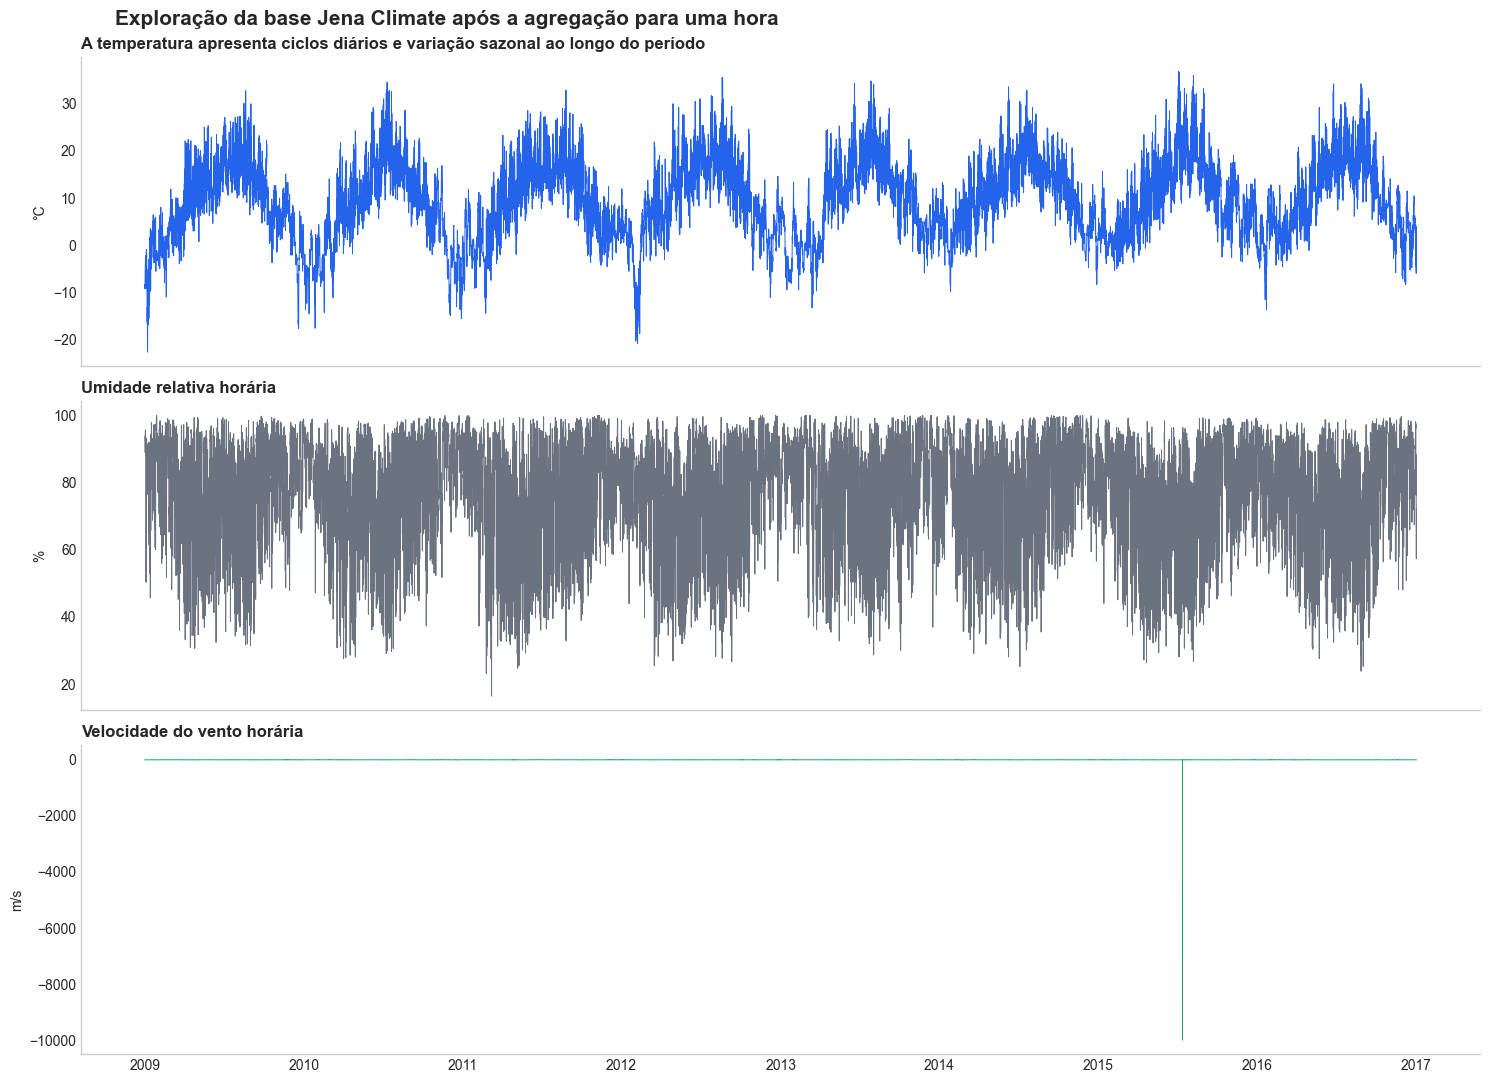

,T (degC)
T (degC),1.000
Tpot (K),0.997
VPmax (mbar),0.951
Tdew (degC),0.897
VPact (mbar),0.869
H2OC (mmol/mol),0.869
sh (g/kg),0.868
VPdef (mbar),0.762
wd (deg),0.046
max. wv (m/s),-0.001


In [6]:
# 5. Gráficos exploratórios da série-alvo e das principais variáveis externas
plot_step = max(1, len(hourly) // 20_000)
plot_data = hourly.iloc[::plot_step]

fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)
axes[0].plot(plot_data.index, plot_data[TARGET], color='#2563EB', linewidth=0.7)
axes[0].set_title('A temperatura apresenta ciclos diários e variação sazonal ao longo do período', loc='left')
axes[0].set_ylabel('°C')
axes[1].plot(plot_data.index, plot_data['rh (%)'], color='#6B7280', linewidth=0.7)
axes[1].set_title('Umidade relativa horária', loc='left')
axes[1].set_ylabel('%')
axes[2].plot(plot_data.index, plot_data['wv (m/s)'], color='#21A366', linewidth=0.7)
axes[2].set_title('Velocidade do vento horária', loc='left')
axes[2].set_ylabel('m/s')
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(False)
fig.suptitle('Exploração da base Jena Climate após a agregação para uma hora', x=0.08, ha='left', fontsize=15, fontweight='bold')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'eda_series.png', dpi=140, bbox_inches='tight')
plt.show()

# Relação contemporânea apenas para exploração; não será usada como evidência de causalidade.
eda_corr = hourly.select_dtypes(include='number').corr()[[TARGET]].sort_values(TARGET, ascending=False)
display(eda_corr.style.format('{:.3f}'))


## 4. Decomposição STL e força da sazonalidade

A decomposição STL separa a série em:

\[
Y_t = T_t + S_t + R_t,
\]

onde `T_t` é a tendência, `S_t` a sazonalidade e `R_t` o resíduo. Como a frequência final é horária, o período diário utilizado é `m = 24`.

A força da sazonalidade será calculada por:

\[
F_s = \max\left(0, 1 - \frac{Var(R_t)}{Var(S_t + R_t)}\right).
\]

Valores próximos de 1 indicam que a parte sazonal explica uma parcela importante da variação não tendencial; valores próximos de 0 indicam sazonalidade fraca. A métrica não prova causalidade: ela descreve a decomposição escolhida.


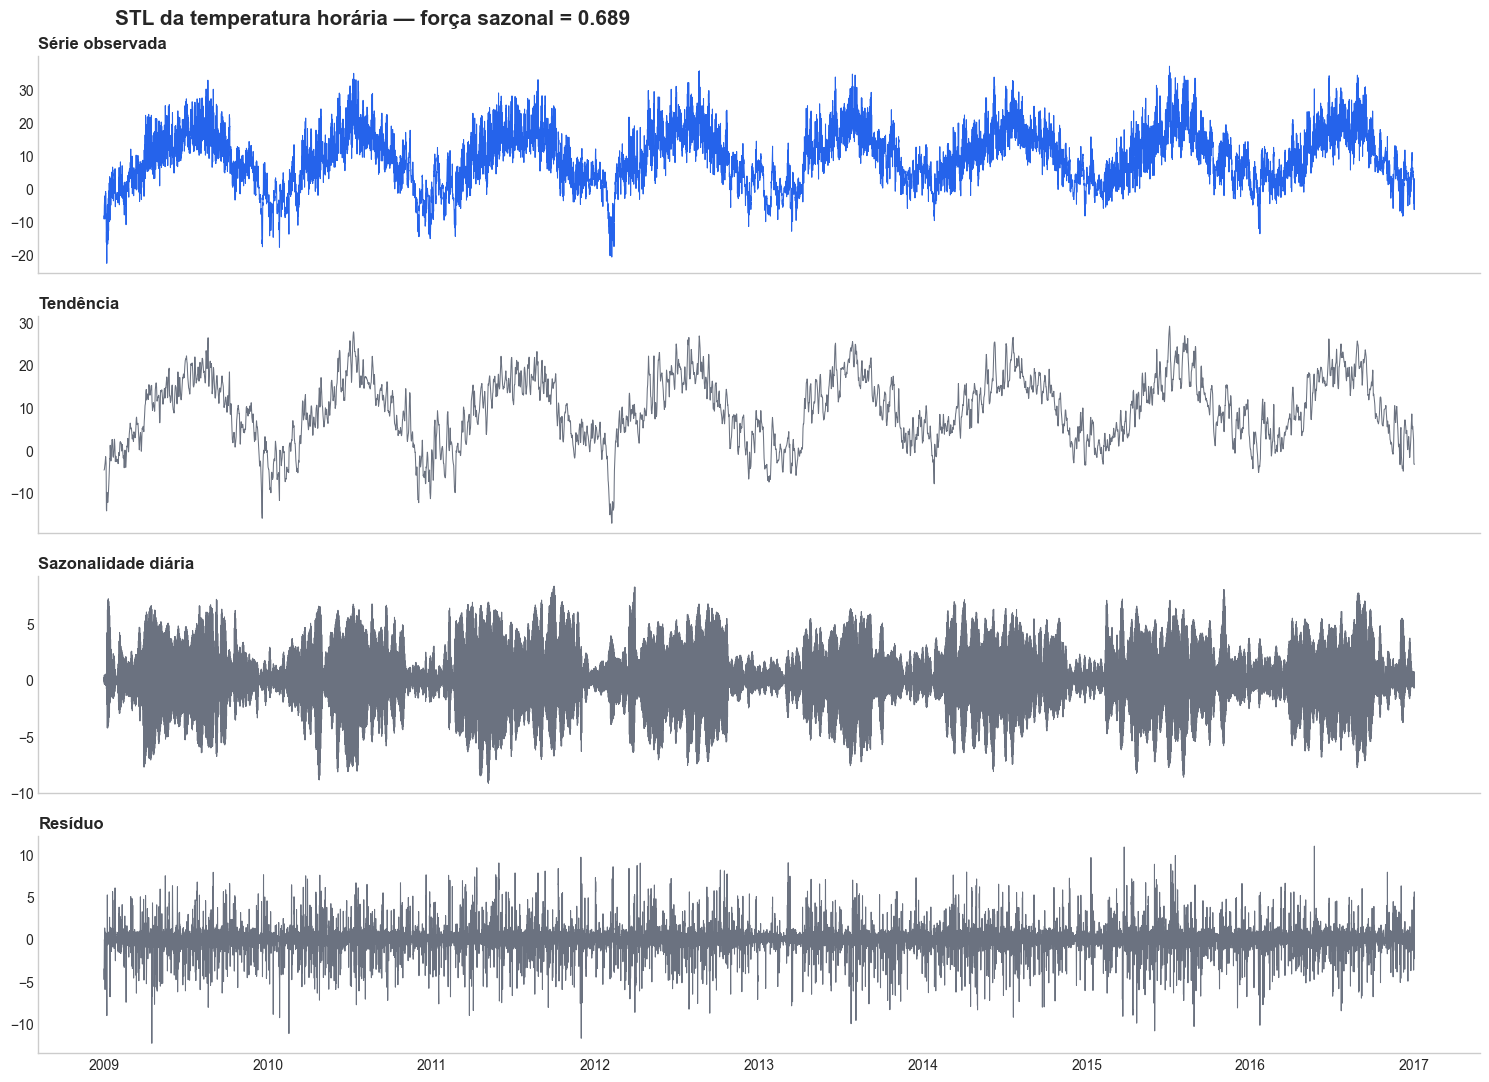

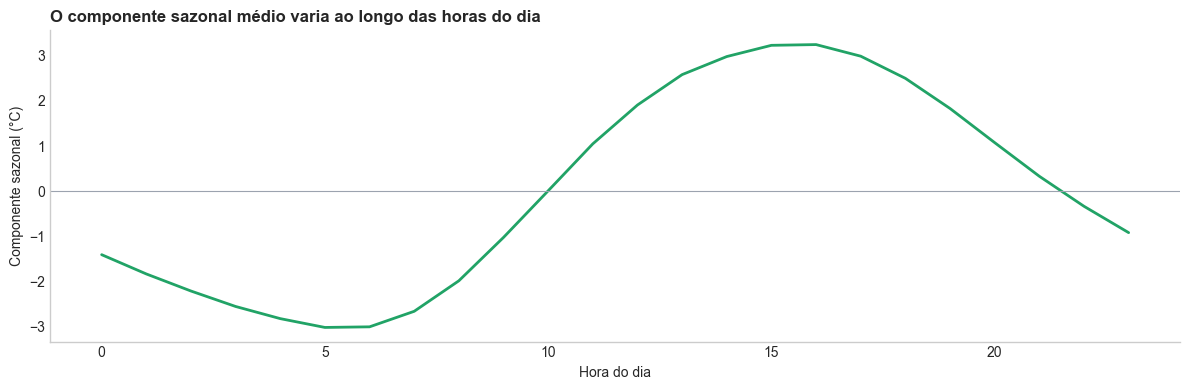

Força estimada da sazonalidade diária: 0.6889
Tendência STL: mínimo=-17.12 °C; máximo=29.10 °C


,inicio_mes,tendencia_media,variacao_vs_mes_anterior
0,2009-01-01,-3.259805,NaN
1,2009-02-01,0.219369,3.479174
2,2009-03-01,4.174068,3.954699
3,2009-04-01,12.502814,8.328746
4,2009-05-01,13.309595,0.806781
5,2009-06-01,14.278365,0.968770
6,2009-07-01,17.904115,3.625750
7,2009-08-01,19.100248,1.196133
8,2009-09-01,14.241559,-4.858689
9,2009-10-01,7.455031,-6.786528


In [7]:
# 6. STL, força da sazonalidade e perfil horário
stl_series = hourly[TARGET].dropna()
stl = STL(stl_series, period=SEASONAL_PERIOD, robust=True).fit()
stl_components = pd.DataFrame({
    'observed': stl.observed,
    'trend': stl.trend,
    'seasonal': stl.seasonal,
    'resid': stl.resid,
})
stl_components.to_csv(OUTPUT_DIR / 'stl_components.csv')

seasonal_denominator = np.var(stl.seasonal + stl.resid)
seasonal_strength = float(max(0, 1 - np.var(stl.resid) / seasonal_denominator)) if seasonal_denominator > 0 else np.nan

stl_summary = {
    'period_hours': SEASONAL_PERIOD,
    'observations': len(stl_series),
    'seasonal_strength': seasonal_strength,
    'trend_min': float(np.nanmin(stl.trend)),
    'trend_max': float(np.nanmax(stl.trend)),
    'residual_mean': float(np.nanmean(stl.resid)),
    'residual_std': float(np.nanstd(stl.resid)),
}
save_json('stl_summary.json', stl_summary)

sampled_stl = stl_components.iloc[::max(1, len(stl_components) // 20_000)]
fig, axes = plt.subplots(4, 1, figsize=(15, 11), sharex=True)
for ax, column, title in zip(
    axes,
    ['observed', 'trend', 'seasonal', 'resid'],
    ['Série observada', 'Tendência', 'Sazonalidade diária', 'Resíduo'],
):
    ax.plot(sampled_stl.index, sampled_stl[column], color='#2563EB' if column == 'observed' else '#6B7280', linewidth=0.75)
    ax.set_title(title, loc='left')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(False)
fig.suptitle(f'STL da temperatura horária — força sazonal = {seasonal_strength:.3f}', x=0.08, ha='left', fontsize=15, fontweight='bold')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'stl_decomposition.png', dpi=140, bbox_inches='tight')
plt.show()

seasonal_profile = stl_components.assign(hour=stl_components.index.hour).groupby('hour')['seasonal'].mean()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(seasonal_profile.index, seasonal_profile.values, color='#21A366', linewidth=2)
ax.axhline(0, color='#9CA3AF', linewidth=0.8)
ax.set_title('O componente sazonal médio varia ao longo das horas do dia', loc='left')
ax.set_xlabel('Hora do dia')
ax.set_ylabel('Componente sazonal (°C)')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'stl_daily_seasonal_profile.png', dpi=140, bbox_inches='tight')
plt.show()

trend_monthly = stl_components['trend'].resample('MS').mean().dropna()
trend_summary = pd.DataFrame({
    'inicio_mes': trend_monthly.index,
    'tendencia_media': trend_monthly.values,
    'variacao_vs_mes_anterior': trend_monthly.diff().values,
})
trend_summary.to_csv(OUTPUT_DIR / 'stl_monthly_trend.csv', index=False)
print(f'Força estimada da sazonalidade diária: {seasonal_strength:.4f}')
print(f'Tendência STL: mínimo={stl_summary["trend_min"]:.2f} °C; máximo={stl_summary["trend_max"]:.2f} °C')
display(trend_summary.head(12))


## 5. Feature Engineering causal

Os modelos tabulares usam um conjunto compartilhado de atributos para tornar a comparação justa:

- lags do alvo em 0, 1, 2, 3, 6, 12, 24, 48, 72 e 168 horas;
- médias e desvios móveis calculados depois de deslocar o alvo uma hora;
- lags das variáveis meteorológicas;
- para a direção do vento, seno e cosseno dos ângulos, evitando a descontinuidade entre 359° e 0°;
- codificação cíclica da hora, do dia da semana e do dia do ano do instante futuro;
- o calendário futuro é permitido, enquanto as condições meteorológicas futuras observadas não são.

A primeira linha válida só aparece depois do maior lag/janela. Linhas sem features ou alvo completo são descartadas, sem imputação usando o futuro.


In [8]:
# 7. Construção das features causais compartilhadas por RF e PLS
TARGET_LAGS = (0, 1, 2, 3, 6, 12, 24, 48, 72, 168)
EXOG_LAGS = (0, 1, 2, 3, 6, 12, 24, 48, 72, 168)
ROLLING_WINDOWS = (3, 6, 12, 24, 168)


def slugify(value):
    return re.sub(r'[^0-9A-Za-z]+', '_', str(value)).strip('_').lower() or 'feature'


def build_supervised_features(frame, target, horizon=1):
    index = frame.index
    timestamp_series = pd.Series(index, index=index)
    feature_values = {}
    feature_dictionary_rows = []
    direction_column = find_wind_direction(frame.columns)
    external_columns = [
        column for column in frame.columns
        if column != target and pd.api.types.is_numeric_dtype(frame[column])
    ]

    def add_feature(name, values, group, source, availability):
        feature_values[name] = values
        feature_dictionary_rows.append({
            'feature': name,
            'group': group,
            'source': source,
            'availability': availability,
        })

    for lag in TARGET_LAGS:
        add_feature(
            f'target_lag_{lag}',
            frame[target].shift(lag),
            'target_lag',
            target,
            f'observado na origem; defasagem de {lag} hora(s)',
        )

    historical_target = frame[target].shift(1)
    for window in ROLLING_WINDOWS:
        add_feature(
            f'target_roll_mean_{window}',
            historical_target.rolling(window=window, min_periods=window).mean(),
            'rolling',
            target,
            f'histórico estritamente anterior à origem; janela de {window} hora(s)',
        )
        add_feature(
            f'target_roll_std_{window}',
            historical_target.rolling(window=window, min_periods=window).std(),
            'rolling',
            target,
            f'histórico estritamente anterior à origem; janela de {window} hora(s)',
        )

    for column in external_columns:
        column_slug = slugify(column)
        if column == direction_column:
            radians = np.deg2rad(frame[column])
            for lag in EXOG_LAGS:
                add_feature(
                    f'{column_slug}_sin_lag_{lag}',
                    np.sin(radians).shift(lag),
                    'exog_lag',
                    column,
                    f'observado na origem; defasagem de {lag} hora(s)',
                )
                add_feature(
                    f'{column_slug}_cos_lag_{lag}',
                    np.cos(radians).shift(lag),
                    'exog_lag',
                    column,
                    f'observado na origem; defasagem de {lag} hora(s)',
                )
        else:
            for lag in EXOG_LAGS:
                add_feature(
                    f'{column_slug}_lag_{lag}',
                    frame[column].shift(lag),
                    'exog_lag',
                    column,
                    f'observado na origem; defasagem de {lag} hora(s)',
                )

    # Calendário do instante futuro: conhecido antecipadamente na origem.
    for step in range(1, horizon + 1):
        future_time = timestamp_series.shift(-step)
        minute_of_day = future_time.dt.hour * 60 + future_time.dt.minute
        day_of_week = future_time.dt.dayofweek
        day_of_year = future_time.dt.dayofyear
        calendar_features = [
            ('hour_sin', np.sin(2 * np.pi * minute_of_day / 1440), 1440),
            ('hour_cos', np.cos(2 * np.pi * minute_of_day / 1440), 1440),
            ('dow_sin', np.sin(2 * np.pi * day_of_week / 7), 7),
            ('dow_cos', np.cos(2 * np.pi * day_of_week / 7), 7),
            ('doy_sin', np.sin(2 * np.pi * day_of_year / 365.25), 365.25),
            ('doy_cos', np.cos(2 * np.pi * day_of_year / 365.25), 365.25),
        ]
        for name, values, period in calendar_features:
            add_feature(
                f'calendar_{name}_t_plus_{step}',
                pd.Series(values, index=index),
                'calendar',
                f'timestamp t+{step}',
                f'conhecido antecipadamente; ciclo de {period}',
            )

    x = pd.DataFrame(feature_values, index=index)
    y = pd.DataFrame(
        {f'target_t_plus_{step}': frame[target].shift(-step) for step in range(1, horizon + 1)},
        index=index,
    )
    meta = pd.DataFrame({
        'origin_pos': np.arange(len(frame), dtype=int),
        'target_end_pos': np.arange(len(frame), dtype=int) + horizon,
        'origin_time': index,
        **{
            f'target_time_{step}': timestamp_series.shift(-step).values
            for step in range(1, horizon + 1)
        },
    }, index=index)

    valid = x.notna().all(axis=1) & y.notna().all(axis=1)
    x = x.loc[valid].reset_index(drop=True)
    y = y.loc[valid].reset_index(drop=True)
    meta = meta.loc[valid].reset_index(drop=True)
    dictionary = pd.DataFrame(feature_dictionary_rows)
    return x, y, meta, dictionary


X, Y, meta, feature_dictionary = build_supervised_features(hourly, TARGET, HORIZON)
feature_dictionary.to_csv(OUTPUT_DIR / 'feature_dictionary.csv', index=False)

# O corte é feito na série horária bruta, antes da remoção das linhas iniciais dos lags.
split_origin = int(len(hourly) * TRAIN_FRACTION)
train_mask = meta['target_end_pos'] < split_origin
test_mask = meta['target_end_pos'] >= split_origin

X_train = X.loc[train_mask].reset_index(drop=True)
Y_train = Y.loc[train_mask].reset_index(drop=True)
meta_train = meta.loc[train_mask].reset_index(drop=True)
X_test = X.loc[test_mask].reset_index(drop=True)
Y_test = Y.loc[test_mask].reset_index(drop=True)
meta_test = meta.loc[test_mask].reset_index(drop=True)

# Todas as previsões fora da amostra usam exatamente estas origens.
COMMON_ORIGINS = meta_test['origin_pos'].astype(int).to_numpy()
if len(COMMON_ORIGINS) == 0:
    raise RuntimeError('O corte 80/20 não produziu origens de teste válidas.')

print(f'Features criadas: {X.shape[1]}')
print(f'Linhas supervisionadas: {len(X):,}')
print(f'Treino: {len(X_train):,}; teste: {len(X_test):,}')
print(f'Corte temporal: posição {split_origin:,} de {len(hourly):,}')
print(f'Primeiro alvo de teste: {meta_test.target_time_1.iloc[0]}')
print(f'Último alvo de teste: {meta_test.target_time_1.iloc[-1]}')
display(feature_dictionary.groupby('group').size().rename('quantidade').to_frame())


Features criadas: 166
Linhas supervisionadas: 69,020
Treino: 55,238; teste: 13,782
Corte temporal: posição 56,102 de 70,128
Primeiro alvo de teste: 2015-05-27 15:00:00
Último alvo de teste: 2017-01-01 00:00:00


,quantidade
group,
calendar,6
exog_lag,140
rolling,10
target_lag,10


## 6. Busca temporal de hiperparâmetros e funções de avaliação

A seleção usa `TimeSeriesSplit` com `gap = 1`. O conjunto de teste não participa da escolha dos parâmetros. Para limitar o custo sem alterar a ordem temporal, a busca usa somente as últimas 4.380 linhas do bloco de desenvolvimento, aproximadamente seis meses; a avaliação final continua usando todo o período de teste.

Durante o walk-forward:

- os hiperparâmetros escolhidos ficam congelados;
- as origens são as mesmas para os quatro modelos;
- Random Forest e PLS são reajustados a cada 168 horas usando uma janela móvel de treino;
- SARIMAX e Holt–Winters atualizam o estado com a observação que se torna disponível;
- cada previsão é registrada com origem, alvo, valor real, valor previsto, resíduo e erro absoluto.


In [9]:
# 8. Métrica, busca temporal e walk-forward para modelos tabulares

def scalar_mae(actual, predicted):
    return float(mean_absolute_error(np.asarray(actual).reshape(-1), np.asarray(predicted).reshape(-1)))


def params_to_json(params):
    return json.dumps(params, ensure_ascii=False, default=json_default)


def search_tabular_model(model_name, candidates, x, y, factory):
    if len(x) > SEARCH_MAX_ROWS:
        x_search = x.iloc[-SEARCH_MAX_ROWS:].reset_index(drop=True)
        y_search = y.iloc[-SEARCH_MAX_ROWS:].reset_index(drop=True)
    else:
        x_search = x.reset_index(drop=True)
        y_search = y.reset_index(drop=True)

    splitter = TimeSeriesSplit(n_splits=3, gap=HORIZON)
    rows = []
    for candidate_number, params in enumerate(candidates, start=1):
        fold_scores = []
        started = time.perf_counter()
        for fold_number, (train_indices, valid_indices) in enumerate(splitter.split(x_search), start=1):
            model = factory(params, RANDOM_STATE + fold_number)
            model.fit(x_search.iloc[train_indices], y_search.iloc[train_indices])
            prediction = model.predict(x_search.iloc[valid_indices])
            fold_scores.append(scalar_mae(y_search.iloc[valid_indices], prediction))
        elapsed = time.perf_counter() - started
        rows.append({
            'model': model_name,
            'candidate': candidate_number,
            'params': params_to_json(params),
            'mean_cv_mae': float(np.mean(fold_scores)),
            'std_cv_mae': float(np.std(fold_scores, ddof=1)),
            'fold_mae': json.dumps(fold_scores),
            'elapsed_seconds': elapsed,
            'search_rows': len(x_search),
        })

    result = pd.DataFrame(rows).sort_values('mean_cv_mae').reset_index(drop=True)
    best_candidate = int(result.iloc[0]['candidate'])
    best_params = dict(candidates[best_candidate - 1])
    return result, best_params


def walk_forward_tabular(model_name, params, factory, x_all, y_all, meta_all):
    row_by_origin = {int(row.origin_pos): row_position for row_position, row in meta_all.iterrows()}
    predictions = []
    fitted_model = None
    fit_count = 0
    started = time.perf_counter()

    for block_number, origin in enumerate(COMMON_ORIGINS):
        origin = int(origin)
        row_position = row_by_origin.get(origin)
        if row_position is None:
            continue

        # No instante t, todos os alvos até t já foram observados.
        train_positions = np.flatnonzero((meta_all['target_end_pos'] <= origin).to_numpy())
        if len(train_positions) > MAX_TRAIN_ROWS:
            train_positions = train_positions[-MAX_TRAIN_ROWS:]
        if len(train_positions) < max(50, HORIZON * 10):
            continue

        if fitted_model is None or block_number % REFIT_EVERY == 0:
            fitted_model = factory(params, RANDOM_STATE)
            fitted_model.fit(x_all.iloc[train_positions], y_all.iloc[train_positions])
            fit_count += 1

        predicted = np.asarray(fitted_model.predict(x_all.iloc[[row_position]])).reshape(-1)[0]
        actual = float(y_all.iloc[row_position, 0])
        predictions.append({
            'model': model_name,
            'origin_time': meta_all.iloc[row_position]['origin_time'],
            'target_time': meta_all.iloc[row_position]['target_time_1'],
            'horizon': HORIZON,
            'actual': actual,
            'predicted': float(predicted),
            'residual': actual - float(predicted),
            'absolute_error': abs(actual - float(predicted)),
        })

    result = pd.DataFrame(predictions)
    elapsed = time.perf_counter() - started
    return result, fit_count, elapsed


def rf_factory(params, seed=RANDOM_STATE):
    return RandomForestRegressor(
        **dict(params),
        random_state=seed,
        n_jobs=N_JOBS,
    )


def pls_factory(params, seed=RANDOM_STATE):
    params = dict(params)
    # PLSRegression não é estocástico, mas o parâmetro é mantido na assinatura
    # para que todas as fábricas tenham o mesmo protocolo reprodutível.
    params.setdefault('scale', True)
    return PLSRegression(**params)


## 7. Random Forest e PLS Regression — otimização

### Espaços pesquisados

- **Random Forest:** `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf` e `max_features`;
- **PLS Regression:** número de componentes latentes, `scale`, tolerância e número máximo de iterações.

O PLS é particularmente adequado quando as features são numerosas e colineares — situação presente aqui, pois várias variáveis meteorológicas são fisicamente relacionadas e há múltiplos lags do mesmo fenômeno.


In [10]:
# 9. Busca de hiperparâmetros do Random Forest e do PLS
RF_CANDIDATES = list(ParameterSampler(
    {
        'n_estimators': [100, 160],
        'max_depth': [12, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 3],
        'max_features': ['sqrt', 0.7],
    },
    n_iter=6,
    random_state=RANDOM_STATE,
))

PLS_CANDIDATES = [
    {'n_components': 2, 'scale': True, 'max_iter': 500, 'tol': 1e-06},
    {'n_components': 4, 'scale': True, 'max_iter': 500, 'tol': 1e-06},
    {'n_components': 8, 'scale': True, 'max_iter': 500, 'tol': 1e-06},
    {'n_components': 12, 'scale': True, 'max_iter': 500, 'tol': 1e-06},
    {'n_components': 16, 'scale': True, 'max_iter': 500, 'tol': 1e-06},
]

started = time.perf_counter()
rf_search_results, best_rf = search_tabular_model(
    'Random Forest', RF_CANDIDATES, X_train, Y_train, rf_factory
)
rf_search_results.to_csv(OUTPUT_DIR / 'random_forest_hyperparameter_search.csv', index=False)
runtime_records.append({
    'model': 'Random Forest',
    'stage': 'hyperparameter_search',
    'elapsed_seconds': time.perf_counter() - started,
    'selected_params': params_to_json(best_rf),
})

started = time.perf_counter()
pls_search_results, best_pls = search_tabular_model(
    'PLS Regression', PLS_CANDIDATES, X_train, Y_train, pls_factory
)
pls_search_results.to_csv(OUTPUT_DIR / 'pls_hyperparameter_search.csv', index=False)
runtime_records.append({
    'model': 'PLS Regression',
    'stage': 'hyperparameter_search',
    'elapsed_seconds': time.perf_counter() - started,
    'selected_params': params_to_json(best_pls),
})

print('Melhores parâmetros — Random Forest:', best_rf)
print('Melhores parâmetros — PLS Regression:', best_pls)
display(rf_search_results)
display(pls_search_results)


Melhores parâmetros — Random Forest: {'n_estimators': 160, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': 20}
Melhores parâmetros — PLS Regression: {'n_components': 16, 'scale': True, 'max_iter': 500, 'tol': 1e-06}


,model,candidate,params,mean_cv_mae,std_cv_mae,fold_mae,elapsed_seconds,search_rows
0,Random Forest,1,"{""n_estimators"": 160, ""min_samples_split"": 5, ...",0.705694,0.232278,"[0.4489217680748759, 0.7669691429441594, 0.901...",34.699076,4380
1,Random Forest,4,"{""n_estimators"": 160, ""min_samples_split"": 5, ...",0.705877,0.230885,"[0.44989397577437884, 0.7693507469007347, 0.89...",33.069362,4380
2,Random Forest,3,"{""n_estimators"": 100, ""min_samples_split"": 5, ...",0.707532,0.230936,"[0.4532279325706213, 0.7651958592518853, 0.904...",19.181196,4380
3,Random Forest,2,"{""n_estimators"": 100, ""min_samples_split"": 2, ...",0.710957,0.232168,"[0.4532453576864536, 0.77585802130898, 0.90376...",23.597727,4380
4,Random Forest,5,"{""n_estimators"": 100, ""min_samples_split"": 2, ...",0.712804,0.235373,"[0.45216616973826107, 0.7764045519575822, 0.90...",20.446620,4380
5,Random Forest,6,"{""n_estimators"": 160, ""min_samples_split"": 2, ...",1.094170,0.297701,"[0.7546126207970016, 1.2175611537904265, 1.310...",3.677863,4380


,model,candidate,params,mean_cv_mae,std_cv_mae,fold_mae,elapsed_seconds,search_rows
0,PLS Regression,5,"{""n_components"": 16, ""scale"": true, ""max_iter""...",0.559256,0.105663,"[0.4395329714976884, 0.5987540597101211, 0.639...",0.302620,4380
1,PLS Regression,4,"{""n_components"": 12, ""scale"": true, ""max_iter""...",0.623226,0.123087,"[0.49148695663884745, 0.6428994455196918, 0.73...",0.183940,4380
2,PLS Regression,3,"{""n_components"": 8, ""scale"": true, ""max_iter"":...",0.755208,0.121206,"[0.6305975799658942, 0.762331892609959, 0.8726...",0.175090,4380
3,PLS Regression,2,"{""n_components"": 4, ""scale"": true, ""max_iter"":...",1.012689,0.183301,"[0.8048518241553099, 1.081936586713274, 1.1512...",0.106231,4380
4,PLS Regression,1,"{""n_components"": 2, ""scale"": true, ""max_iter"":...",1.544687,0.361934,"[1.2263293635718147, 1.4693811005718709, 1.938...",0.101438,4380


In [ ]:
# 10. Walk-forward final para os modelos tabulares
rf_predictions, rf_fit_count, rf_elapsed = walk_forward_tabular(
    'Random Forest', best_rf, rf_factory, X, Y, meta
)
pls_predictions, pls_fit_count, pls_elapsed = walk_forward_tabular(
    'PLS Regression', best_pls, pls_factory, X, Y, meta
)

runtime_records.extend([
    {
        'model': 'Random Forest',
        'stage': 'walk_forward',
        'elapsed_seconds': rf_elapsed,
        'fit_count': rf_fit_count,
        'selected_params': params_to_json(best_rf),
    },
    {
        'model': 'PLS Regression',
        'stage': 'walk_forward',
        'elapsed_seconds': pls_elapsed,
        'fit_count': pls_fit_count,
        'selected_params': params_to_json(best_pls),
    },
])

print(f'Random Forest: {len(rf_predictions):,} previsões; {rf_fit_count} reajustes; MAE={rf_predictions.absolute_error.mean():.5f} °C')
print(f'PLS Regression: {len(pls_predictions):,} previsões; {pls_fit_count} reajustes; MAE={pls_predictions.absolute_error.mean():.5f} °C')


## 8. SARIMAX com exógenas disponíveis na origem

O SARIMAX combina uma dinâmica autoregressiva/média móvel com diferenciação sazonal e regressoras externas. Para não usar condições meteorológicas futuras observadas, são usadas cinco exógenas compactas:

- pressão (`p`);
- umidade relativa (`rh`);
- velocidade do vento (`wv`);
- seno e cosseno da direção do vento.

Cada uma é deslocada uma hora. Assim, para explicar `T[t]`, o modelo recebe as condições de `t-1`; para prever `T[t+1]` na origem `t`, recebe as condições de `t`, que já foram observadas.

A pesquisa usa um bloco de validação temporal de 168 horas dentro do desenvolvimento. O teste final permanece intocado.


In [ ]:
# 11. SARIMAX: exógenas defasadas, busca e ajuste
SARIMAX_BASE_EXOG = ['p (mbar)', 'rh (%)', 'wv (m/s)']
sarimax_exog_current = hourly[SARIMAX_BASE_EXOG].copy()
sarimax_exog_current['wd_sin'] = np.sin(np.deg2rad(hourly['wd (deg)']))
sarimax_exog_current['wd_cos'] = np.cos(np.deg2rad(hourly['wd (deg)']))
sarimax_exog_lagged = sarimax_exog_current.shift(1)

SARIMAX_CANDIDATES = [
    {'order': (1, 0, 1), 'seasonal_order': (0, 1, 1, 24)},
    {'order': (2, 0, 1), 'seasonal_order': (0, 1, 1, 24)},
    {'order': (1, 1, 1), 'seasonal_order': (0, 1, 1, 24)},
    {'order': (1, 0, 2), 'seasonal_order': (1, 1, 0, 24)},
]


def fit_sarimax(params, endog, exog):
    valid = endog.notna() & exog.notna().all(axis=1)
    endog = endog.loc[valid]
    exog = exog.loc[valid]
    scaler = StandardScaler()
    exog_scaled = pd.DataFrame(
        scaler.fit_transform(exog), index=exog.index, columns=exog.columns
    )
    model = SARIMAX(
        endog,
        exog=exog_scaled,
        order=tuple(params['order']),
        seasonal_order=tuple(params['seasonal_order']),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    result = model.fit(disp=False, maxiter=50, low_memory=False)
    return result, scaler


def scale_exog(scaler, exog):
    return pd.DataFrame(
        scaler.transform(exog), index=exog.index, columns=exog.columns
    )


SARIMAX_VALIDATION_SIZE = 168
sarimax_validation_start = split_origin - SARIMAX_VALIDATION_SIZE
sarimax_search_start = max(1, sarimax_validation_start - SARIMAX_MAX_TRAIN_ROWS)
sarimax_fit_rows = np.arange(sarimax_search_start, sarimax_validation_start)
sarimax_valid_rows = np.arange(sarimax_validation_start, split_origin)

sarimax_search_rows = []
for candidate_number, params in enumerate(SARIMAX_CANDIDATES, start=1):
    started = time.perf_counter()
    y_fit = hourly[TARGET].iloc[sarimax_fit_rows]
    x_fit = sarimax_exog_lagged.iloc[sarimax_fit_rows]
    y_valid = hourly[TARGET].iloc[sarimax_valid_rows]
    x_valid = sarimax_exog_lagged.iloc[sarimax_valid_rows]

    result, scaler = fit_sarimax(params, y_fit, x_fit)
    x_valid_scaled = scale_exog(scaler, x_valid)
    prediction = result.get_forecast(steps=len(y_valid), exog=x_valid_scaled).predicted_mean
    validation_mae = scalar_mae(y_valid, prediction)
    elapsed = time.perf_counter() - started
    sarimax_search_rows.append({
        'model': 'SARIMAX',
        'candidate': candidate_number,
        'params': params_to_json(params),
        'validation_mae': validation_mae,
        'aic': float(result.aic),
        'bic': float(result.bic),
        'fit_rows': len(y_fit),
        'validation_rows': len(y_valid),
        'elapsed_seconds': elapsed,
    })

sarimax_search_results = pd.DataFrame(sarimax_search_rows).sort_values('validation_mae').reset_index(drop=True)
best_sarimax = dict(SARIMAX_CANDIDATES[int(sarimax_search_results.iloc[0]['candidate']) - 1])
sarimax_search_results.to_csv(OUTPUT_DIR / 'sarimax_hyperparameter_search.csv', index=False)
runtime_records.append({
    'model': 'SARIMAX',
    'stage': 'hyperparameter_search',
    'elapsed_seconds': float(sarimax_search_results['elapsed_seconds'].sum()),
    'selected_params': params_to_json(best_sarimax),
})

print('Melhores parâmetros — SARIMAX:', best_sarimax)
display(sarimax_search_results)


Melhores parâmetros — SARIMAX: {'order': (2, 0, 1), 'seasonal_order': (0, 1, 1, 24)}


,model,candidate,params,validation_mae,aic,bic,fit_rows,validation_rows,elapsed_seconds
0,SARIMAX,2,"{""order"": [2, 0, 1], ""seasonal_order"": [0, 1, ...",1.958638,1411.823809,1456.896586,720,168,11.157135
1,SARIMAX,1,"{""order"": [1, 0, 1], ""seasonal_order"": [0, 1, ...",2.293643,1432.464351,1473.029851,720,168,9.068321
2,SARIMAX,4,"{""order"": [1, 0, 2], ""seasonal_order"": [1, 1, ...",2.862063,1618.529835,1663.617527,720,168,6.760865
3,SARIMAX,3,"{""order"": [1, 1, 1], ""seasonal_order"": [0, 1, ...",5.273872,1426.405189,1466.957245,720,168,7.857568


In [ ]:
# 12. SARIMAX final e atualização walk-forward do estado
first_origin = int(COMMON_ORIGINS[0])
sarimax_train_start = max(1, first_origin + 1 - SARIMAX_MAX_TRAIN_ROWS)
sarimax_train_end = first_origin + 1  # inclui a observação conhecida na primeira origem

y_sarimax_train = hourly[TARGET].iloc[sarimax_train_start:sarimax_train_end]
x_sarimax_train = sarimax_exog_lagged.iloc[sarimax_train_start:sarimax_train_end]

started = time.perf_counter()
sarimax_result, sarimax_scaler = fit_sarimax(best_sarimax, y_sarimax_train, x_sarimax_train)
sarimax_state = sarimax_result
sarimax_predictions_rows = []

last_state_pos = first_origin
for block_number, origin in enumerate(COMMON_ORIGINS):
    origin = int(origin)
    # A base completa tem lacunas horárias. O estado recebe todos os instantes
    # desde a última posição incorporada até a origem atual; alvos faltantes
    # permanecem como NaN no filtro de Kalman e não são imputados.
    if block_number > 0 and origin > last_state_pos:
        extension_index = pd.date_range(
            hourly.index[last_state_pos + 1],
            hourly.index[origin],
            freq=FREQ,
        )
        observed_y = hourly[TARGET].iloc[last_state_pos + 1:origin + 1].copy()
        observed_x = sarimax_exog_lagged.iloc[last_state_pos + 1:origin + 1].copy()
        observed_y.index = extension_index
        observed_x.index = extension_index
        observed_x_scaled = scale_exog(sarimax_scaler, observed_x)
        sarimax_state = sarimax_state.extend(endog=observed_y, exog=observed_x_scaled)
    last_state_pos = origin

    next_exog = sarimax_exog_lagged.iloc[[origin + HORIZON]].copy()
    next_exog.index = pd.date_range(hourly.index[origin + HORIZON], periods=1, freq=FREQ)
    next_exog_scaled = scale_exog(sarimax_scaler, next_exog)
    prediction = float(np.asarray(
        sarimax_state.get_forecast(steps=HORIZON, exog=next_exog_scaled).predicted_mean
    ).reshape(-1)[0])
    target_position = origin + HORIZON
    actual = float(hourly[TARGET].iloc[target_position])
    sarimax_predictions_rows.append({
        'model': 'SARIMAX',
        'origin_time': hourly.index[origin],
        'target_time': hourly.index[target_position],
        'horizon': HORIZON,
        'actual': actual,
        'predicted': prediction,
        'residual': actual - prediction,
        'absolute_error': abs(actual - prediction),
    })

sarimax_predictions = pd.DataFrame(sarimax_predictions_rows)
sarimax_elapsed = time.perf_counter() - started
runtime_records.append({
    'model': 'SARIMAX',
    'stage': 'walk_forward',
    'elapsed_seconds': sarimax_elapsed,
    'fit_count': 1,
    'selected_params': params_to_json(best_sarimax),
})

# Coeficientes das exógenas padronizadas e p-valores para interpretação.
sarimax_param_values = np.asarray(sarimax_result.params)
sarimax_pvalues = np.asarray(sarimax_result.pvalues)
sarimax_terms = list(getattr(sarimax_result.model, 'param_names', []))
sarimax_coefficients = pd.DataFrame({
    'term': sarimax_terms,
    'coefficient_standardized_exog': sarimax_param_values,
    'p_value': sarimax_pvalues,
})
sarimax_coefficients.to_csv(OUTPUT_DIR / 'sarimax_coefficients.csv', index=False)

print(f'SARIMAX: {len(sarimax_predictions):,} previsões; MAE={sarimax_predictions.absolute_error.mean():.5f} °C')
print(f'BIC do ajuste SARIMAX final: {sarimax_result.bic:.2f}')
display(sarimax_coefficients)


SARIMAX: 13,782 previsões; MAE=0.80175 °C
BIC do ajuste SARIMAX final: 1403.55


,term,coefficient_standardized_exog,p_value
0,p (mbar),-1.045486,3.565726e-02
1,rh (%),0.873440,8.546039e-12
2,wv (m/s),-0.084373,5.037876e-02
3,wd_sin,0.023002,3.698571e-01
4,wd_cos,-0.057251,9.933160e-02
5,ar.L1,1.225529,3.880824e-96
6,ar.L2,-0.262242,4.476675e-06
7,ma.L1,0.360074,7.351250e-08
8,ma.S.L24,-0.989979,7.044744e-10
9,sigma2,0.395401,2.188533e-11


## 9. Holt–Winters como referência univariada

O Holt–Winters não recebe variáveis externas, conforme a regra explícita do PDF. Ele representa a temperatura por nível, tendência e sazonalidade; suas condições meteorológicas externas não entram no ajuste.

São comparadas configurações com:

- tendência aditiva ou sem tendência;
- sazonalidade aditiva ou sem sazonalidade;
- tendência amortecida ou não amortecida;
- período sazonal de 24 horas.

Os parâmetros de suavização (`alpha`, `beta` e `gamma`) são otimizados pelo `statsmodels` no ajuste e são registrados no resultado final.


In [ ]:
# 13. Holt-Winters: estado, busca temporal e walk-forward
HW_CANDIDATES = [
    {'trend': 'add', 'seasonal': 'add', 'damped_trend': False, 'seasonal_periods': 24},
    {'trend': 'add', 'seasonal': 'add', 'damped_trend': True, 'seasonal_periods': 24},
    {'trend': None, 'seasonal': 'add', 'damped_trend': False, 'seasonal_periods': 24},
    {'trend': 'add', 'seasonal': None, 'damped_trend': False, 'seasonal_periods': 24},
]


def fit_hw(params, series):
    kwargs = {
        'trend': params['trend'],
        'seasonal': params['seasonal'],
        'damped_trend': params['damped_trend'],
        'initialization_method': 'estimated',
    }
    if params['seasonal'] is not None:
        kwargs['seasonal_periods'] = params['seasonal_periods']
    return ExponentialSmoothing(series, **kwargs).fit(optimized=True, use_brute=True)


def make_hw_state(result, params):
    fitted_params = result.params
    level = float(np.asarray(result.level)[-1])
    trend = float(np.asarray(result.trend)[-1]) if params['trend'] is not None else 0.0
    if params['seasonal'] is not None:
        seasonal_values = list(np.asarray(result.season)[-params['seasonal_periods']:])
        seasonal = deque(seasonal_values, maxlen=params['seasonal_periods'])
    else:
        seasonal = None

    def finite_or_default(value, default):
        try:
            value = float(value)
            return value if np.isfinite(value) else default
        except (TypeError, ValueError):
            return default

    alpha = finite_or_default(fitted_params.get('smoothing_level'), 0.2)
    beta = finite_or_default(fitted_params.get('smoothing_trend'), 0.05) if params['trend'] is not None else 0.0
    gamma = finite_or_default(fitted_params.get('smoothing_seasonal'), 0.05) if params['seasonal'] is not None else 0.0
    phi = finite_or_default(fitted_params.get('damping_trend'), 0.98) if params['damped_trend'] else 1.0

    return {
        'level': level,
        'trend': trend,
        'seasonal': seasonal,
        'alpha': alpha,
        'beta': beta,
        'gamma': gamma,
        'phi': phi,
        'params': params,
    }


def hw_update(state, observed):
    params = state['params']
    level = state['level']
    trend = state['trend']
    phi = state['phi']
    seasonal = state['seasonal']

    if seasonal is not None:
        seasonal_lag = seasonal[0]
        new_level = state['alpha'] * (observed - seasonal_lag) + (1 - state['alpha']) * (level + phi * trend)
        new_trend = state['beta'] * (new_level - level) + (1 - state['beta']) * phi * trend
        new_season = state['gamma'] * (observed - new_level) + (1 - state['gamma']) * seasonal_lag
        seasonal.append(new_season)
    else:
        new_level = state['alpha'] * observed + (1 - state['alpha']) * (level + phi * trend)
        new_trend = state['beta'] * (new_level - level) + (1 - state['beta']) * phi * trend

    state['level'] = float(new_level)
    state['trend'] = float(new_trend)


def hw_forecast_one(state):
    seasonal_value = state['seasonal'][0] if state['seasonal'] is not None else 0.0
    return float(state['level'] + state['phi'] * state['trend'] + seasonal_value)


HW_VALIDATION_SIZE = 168
hw_fit_end = split_origin - HW_VALIDATION_SIZE
hw_fit_series = hourly[TARGET].iloc[:hw_fit_end].dropna()
hw_valid_series = hourly[TARGET].iloc[hw_fit_end:split_origin].dropna()
hw_search_rows = []

for candidate_number, params in enumerate(HW_CANDIDATES, start=1):
    started = time.perf_counter()
    result = fit_hw(params, hw_fit_series)
    state = make_hw_state(result, params)
    predictions = []
    for observed in hw_valid_series:
        predictions.append(hw_forecast_one(state))
        hw_update(state, float(observed))
    elapsed = time.perf_counter() - started
    hw_search_rows.append({
        'model': 'Holt-Winters',
        'candidate': candidate_number,
        'params': params_to_json(params),
        'validation_mae': scalar_mae(hw_valid_series, predictions),
        'aic': float(result.aic),
        'bic': float(result.bic),
        'elapsed_seconds': elapsed,
    })

hw_search_results = pd.DataFrame(hw_search_rows).sort_values('validation_mae').reset_index(drop=True)
best_hw = dict(HW_CANDIDATES[int(hw_search_results.iloc[0]['candidate']) - 1])
hw_search_results.to_csv(OUTPUT_DIR / 'holt_winters_hyperparameter_search.csv', index=False)
runtime_records.append({
    'model': 'Holt-Winters',
    'stage': 'hyperparameter_search',
    'elapsed_seconds': float(hw_search_results['elapsed_seconds'].sum()),
    'selected_params': params_to_json(best_hw),
})

display(hw_search_results)
print('Melhores parâmetros — Holt-Winters:', best_hw)


,model,candidate,params,validation_mae,aic,bic,elapsed_seconds
0,Holt-Winters,4,"{""trend"": ""add"", ""seasonal"": null, ""damped_tre...",0.545689,-36112.294628,-36076.568276,0.584139
1,Holt-Winters,2,"{""trend"": ""add"", ""seasonal"": ""add"", ""damped_tr...",0.565430,-47860.383755,-47601.367704,7.949240
2,Holt-Winters,1,"{""trend"": ""add"", ""seasonal"": ""add"", ""damped_tr...",0.592030,-40129.896526,-39879.812063,6.264836
3,Holt-Winters,3,"{""trend"": null, ""seasonal"": ""add"", ""damped_tre...",0.831569,-26390.764711,-26158.543424,0.813826


Melhores parâmetros — Holt-Winters: {'trend': 'add', 'seasonal': None, 'damped_trend': False, 'seasonal_periods': 24}


In [ ]:
# 14. Holt-Winters final e atualização walk-forward
hw_train_series = hourly[TARGET].iloc[:first_origin + 1].dropna()
started = time.perf_counter()
hw_final_result = fit_hw(best_hw, hw_train_series)
hw_state = make_hw_state(hw_final_result, best_hw)
hw_predictions_rows = []

last_hw_pos = first_origin
for block_number, origin in enumerate(COMMON_ORIGINS):
    origin = int(origin)
    # A base completa tem lacunas. Incorporamos, em ordem, todas as
    # observações reais desde a última origem; NaN não é imputado.
    if block_number > 0 and origin > last_hw_pos:
        for observed in hourly[TARGET].iloc[last_hw_pos + 1:origin + 1].dropna():
            hw_update(hw_state, float(observed))
    last_hw_pos = origin
    prediction = hw_forecast_one(hw_state)
    target_position = origin + HORIZON
    actual = float(hourly[TARGET].iloc[target_position])
    hw_predictions_rows.append({
        'model': 'Holt-Winters',
        'origin_time': hourly.index[origin],
        'target_time': hourly.index[target_position],
        'horizon': HORIZON,
        'actual': actual,
        'predicted': prediction,
        'residual': actual - prediction,
        'absolute_error': abs(actual - prediction),
    })

hw_predictions = pd.DataFrame(hw_predictions_rows)
hw_elapsed = time.perf_counter() - started
runtime_records.append({
    'model': 'Holt-Winters',
    'stage': 'walk_forward',
    'elapsed_seconds': hw_elapsed,
    'fit_count': 1,
    'selected_params': params_to_json(best_hw),
})

hw_parameters = {
    key: (float(value) if isinstance(value, (float, np.floating)) else value)
    for key, value in hw_final_result.params.items()
}
save_json('holt_winters_parameters.json', hw_parameters)
print(f'Holt-Winters: {len(hw_predictions):,} previsões; MAE={hw_predictions.absolute_error.mean():.5f} °C')
print('Parâmetros de suavização estimados:')
display(pd.Series(hw_parameters).to_frame('valor'))


Holt-Winters: 13,782 previsões; MAE=0.48322 °C
Parâmetros de suavização estimados:


,valor
smoothing_level,1.0
smoothing_trend,0.836586
smoothing_seasonal,NaN
damping_trend,NaN
initial_level,-8.451454
initial_trend,0.321545
initial_seasons,[]
use_boxcox,False
lamda,None
remove_bias,False


## 10. Comparação dos quatro modelos por MAE

O MAE é calculado sobre as previsões fora da amostra do walk-forward. Como somente a Jena Climate está disponível neste pacote, o ranking abaixo é válido para essa base; não se deve somar MAEs de bases com unidades ou escalas diferentes.

A coluna `bias` é o resíduo médio (`real - previsto`):

- valor positivo indica subestimação média;
- valor negativo indica superestimação média.


,model,MAE,bias,residual_std,n,rank,win,mean_rank_current_base
0,Holt-Winters,0.48322,-0.00006,0.71491,13782,1,1,1
1,Random Forest,0.57012,0.00320,0.87655,13782,2,0,2
2,SARIMAX,0.80175,-0.02480,9.39652,13782,3,0,3
3,PLS Regression,1.00782,-0.02664,13.78420,13782,4,0,4


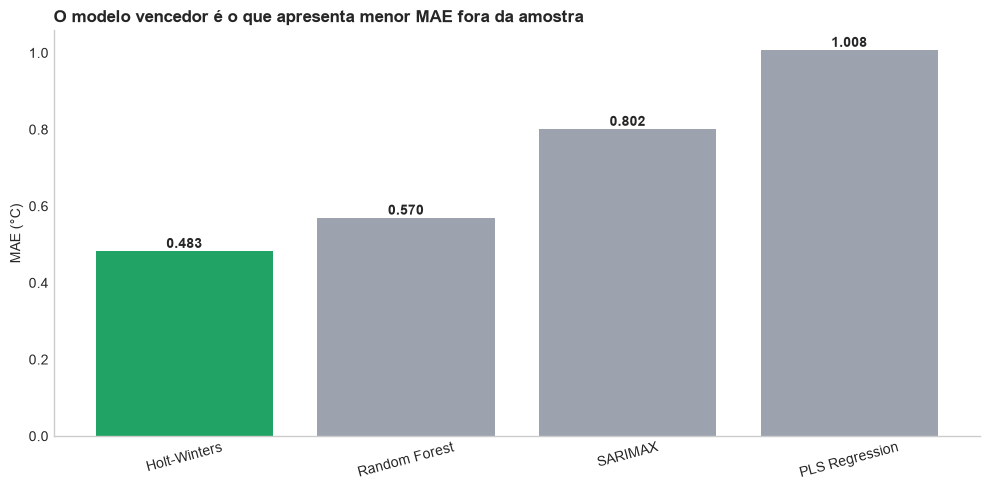

Ranking do menor para o maior MAE:
1. Holt-Winters: 0.48322 °C
2. Random Forest: 0.57012 °C
3. SARIMAX: 0.80175 °C
4. PLS Regression: 1.00782 °C


In [ ]:
# 15. Tabela consolidada de previsões e MAE
all_predictions = pd.concat(
    [sarimax_predictions, hw_predictions, rf_predictions, pls_predictions],
    ignore_index=True,
)
all_predictions['origin_time'] = pd.to_datetime(all_predictions['origin_time'])
all_predictions['target_time'] = pd.to_datetime(all_predictions['target_time'])
all_predictions = all_predictions.sort_values(['model', 'target_time']).reset_index(drop=True)
all_predictions.to_csv(OUTPUT_DIR / 'predictions_long.csv', index=False)

mae_table = (
    all_predictions.groupby('model', as_index=False)
    .agg(
        MAE=('absolute_error', 'mean'),
        bias=('residual', 'mean'),
        residual_std=('residual', 'std'),
        n=('absolute_error', 'size'),
    )
    .sort_values('MAE')
    .reset_index(drop=True)
)
mae_table['rank'] = np.arange(1, len(mae_table) + 1)
mae_table['win'] = (mae_table['rank'] == 1).astype(int)
mae_table['mean_rank_current_base'] = mae_table['rank']
mae_table.to_csv(OUTPUT_DIR / 'model_comparison_mae.csv', index=False)

# Como há uma única base no arquivo recebido, quantidade de vitórias e posição média
# coincidem com o resultado desta base. Com cinco bases, deve-se concatenar os rankings.
model_summary = mae_table[['model', 'win', 'mean_rank_current_base']].rename(
    columns={'win': 'vitorias', 'mean_rank_current_base': 'posicao_media'}
)
model_summary.to_csv(OUTPUT_DIR / 'model_wins_and_mean_rank.csv', index=False)

display(mae_table.style.format({
    'MAE': '{:.5f}',
    'bias': '{:.5f}',
    'residual_std': '{:.5f}',
}))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#21A366' if i == 0 else '#9CA3AF' for i in range(len(mae_table))]
ax.bar(mae_table['model'], mae_table['MAE'], color=colors)
for i, value in enumerate(mae_table['MAE']):
    ax.text(i, value, f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
ax.set_title('O modelo vencedor é o que apresenta menor MAE fora da amostra', loc='left')
ax.set_ylabel('MAE (°C)')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(False)
plt.xticks(rotation=15)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'mae_comparison.png', dpi=140, bbox_inches='tight')
plt.show()

print('Ranking do menor para o maior MAE:')
for _, row in mae_table.iterrows():
    print(f"{int(row['rank'])}. {row['model']}: {row['MAE']:.5f} °C")


## 11. Resíduos, ACF e teste de Ljung–Box

Os resíduos são definidos como `real - previsto`. Para cada modelo são apresentados:

- trajetória temporal dos resíduos;
- ACF dos resíduos;
- teste de Ljung–Box nos lags de 24 horas e 168 horas, quando há observações suficientes.

No teste de Ljung–Box, a hipótese nula é de ausência conjunta de autocorrelação até o lag escolhido. Um p-valor baixo indica estrutura temporal remanescente; não significa, isoladamente, que o modelo seja inútil. O diagnóstico deve ser lido junto com MAE, viés e gráficos.


,model,lag_hours,lb_stat,p_value,residual_mean,residual_std
0,Holt-Winters,24,1511.051,8.81852e-305,-0.00006,0.71491
1,Holt-Winters,168,9333.408,0,-0.00006,0.71491
2,PLS Regression,24,10100.934,0,-0.02664,13.78420
3,PLS Regression,168,14213.348,0,-0.02664,13.78420
4,Random Forest,24,16963.535,0,0.00320,0.87655
5,Random Forest,168,28695.507,0,0.00320,0.87655
6,SARIMAX,24,12983.831,0,-0.02480,9.39652
7,SARIMAX,168,12993.358,0,-0.02480,9.39652


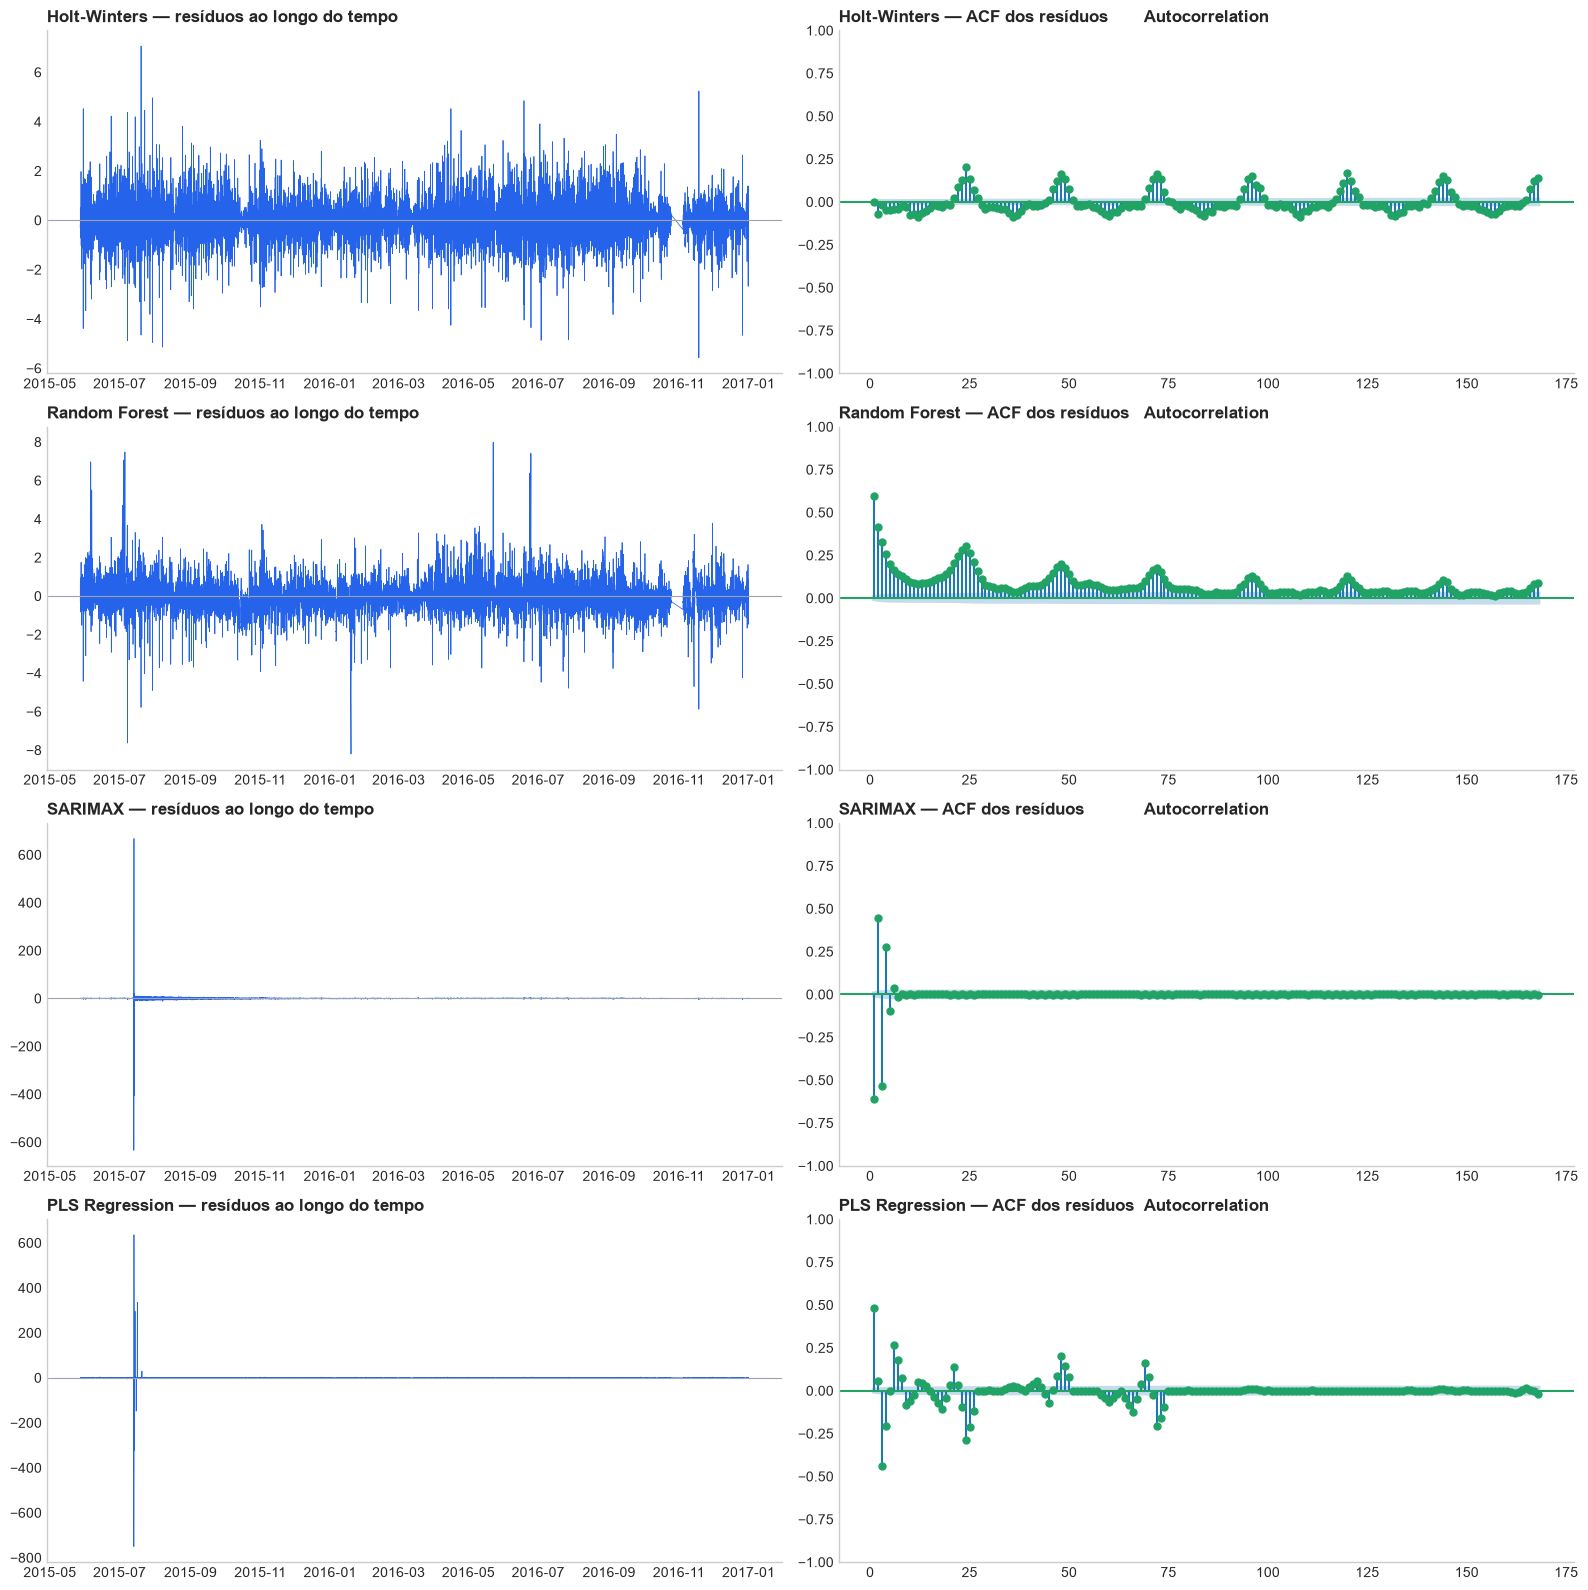

In [ ]:
# 16. Diagnóstico de resíduos, ACF e Ljung-Box
ljung_rows = []
for model_name, group in all_predictions.groupby('model'):
    ordered = group.sort_values('target_time')
    residuals = ordered['residual'].dropna().to_numpy()
    candidate_lags = [lag for lag in [24, 168] if lag < len(residuals) // 5]
    if not candidate_lags:
        candidate_lags = [max(1, len(residuals) // 10)]
    lb = acorr_ljungbox(residuals, lags=candidate_lags, return_df=True)
    for lag, row in lb.iterrows():
        ljung_rows.append({
            'model': model_name,
            'lag_hours': int(lag),
            'lb_stat': float(row['lb_stat']),
            'p_value': float(row['lb_pvalue']),
            'residual_mean': float(residuals.mean()),
            'residual_std': float(residuals.std(ddof=1)),
        })

ljung_table = pd.DataFrame(ljung_rows)
ljung_table.to_csv(OUTPUT_DIR / 'ljung_box_comparison.csv', index=False)
display(ljung_table.style.format({
    'lb_stat': '{:.3f}',
    'p_value': '{:.6g}',
    'residual_mean': '{:.5f}',
    'residual_std': '{:.5f}',
}))

fig, axes = plt.subplots(len(mae_table), 2, figsize=(16, 4 * len(mae_table)), squeeze=False)
for row_index, model_name in enumerate(mae_table['model']):
    group = all_predictions.loc[all_predictions['model'].eq(model_name)].sort_values('target_time')
    residuals = group['residual'].to_numpy()
    axes[row_index, 0].plot(group['target_time'], residuals, color='#2563EB', linewidth=0.55)
    axes[row_index, 0].axhline(0, color='#9CA3AF', linewidth=0.8)
    axes[row_index, 0].set_title(f'{model_name} — resíduos ao longo do tempo', loc='left')
    axes[row_index, 0].spines[['top', 'right']].set_visible(False)
    axes[row_index, 0].grid(False)
    acf_lags = min(168, max(1, len(residuals) // 3 - 1))
    plot_acf(residuals, lags=acf_lags, ax=axes[row_index, 1], color='#21A366', zero=False)
    axes[row_index, 1].set_title(f'{model_name} — ACF dos resíduos', loc='left')
    axes[row_index, 1].spines[['top', 'right']].set_visible(False)
    axes[row_index, 1].grid(False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'residuals_acf_all_models.png', dpi=140, bbox_inches='tight')
plt.show()


## 12. Importância das features e interpretação

A interpretação usa métodos compatíveis com cada família:

- **SARIMAX:** coeficientes das exógenas padronizadas e p-valores;
- **Holt–Winters:** nível, tendência, sazonalidade e parâmetros de suavização;
- **Random Forest:** importância nativa baseada na redução média de impureza;
- **PLS:** VIP Scores, coeficientes e *permutation importance*.

A *permutation importance* é calculada depois do ajuste final no bloco de teste somente para interpretação. Ela não é usada para escolher hiperparâmetros. Importância não implica causalidade; indica contribuição preditiva sob o conjunto e o modelo analisados.


In [ ]:
# 17. Importância do Random Forest e do PLS Regression
started = time.perf_counter()
rf_final = rf_factory(best_rf, RANDOM_STATE).fit(X_train, Y_train)
rf_final_elapsed = time.perf_counter() - started
rf_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance_native': rf_final.feature_importances_,
}).sort_values('importance_native', ascending=False)
rf_importance = rf_importance.merge(feature_dictionary, on='feature', how='left')
rf_importance.to_csv(OUTPUT_DIR / 'random_forest_feature_importance.csv', index=False)


def negative_mae_scorer(estimator, x_values, y_values):
    return -scalar_mae(y_values, estimator.predict(x_values))


started = time.perf_counter()
pls_final = pls_factory(best_pls, RANDOM_STATE).fit(X_train, Y_train)
pls_final_elapsed = time.perf_counter() - started

# Permutation importance na escala original do alvo.
permutation = permutation_importance(
    pls_final,
    X_test,
    Y_test,
    scoring=negative_mae_scorer,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
)

pls_coefficients_values = np.asarray(pls_final.coef_)
if pls_coefficients_values.ndim == 1:
    pls_coefficients_values = pls_coefficients_values.reshape(-1, 1)
if pls_coefficients_values.shape[0] != len(X_train.columns):
    pls_coefficients_values = pls_coefficients_values.T


def pls_vip_scores(model):
    scores = np.asarray(model.x_scores_)
    weights = np.asarray(model.x_weights_)
    loadings_y = np.asarray(model.y_loadings_)
    explained_y_by_component = np.sum(scores ** 2, axis=0) * np.sum(loadings_y ** 2, axis=0)
    total_explained_y = explained_y_by_component.sum()
    if total_explained_y <= 0:
        return np.full(weights.shape[0], np.nan)
    normalized_weights = weights ** 2 / np.sum(weights ** 2, axis=0, keepdims=True)
    return np.sqrt(
        weights.shape[0]
        * (normalized_weights @ explained_y_by_component)
        / total_explained_y
    )


pls_importance = pd.DataFrame({
    'feature': X_test.columns,
    'permutation_importance_mean': permutation.importances_mean,
    'permutation_importance_std': permutation.importances_std,
    'coefficient': pls_coefficients_values[:, 0],
    'absolute_coefficient': np.abs(pls_coefficients_values[:, 0]),
    'vip_score': pls_vip_scores(pls_final),
}).sort_values('permutation_importance_mean', ascending=False)
pls_importance = pls_importance.merge(feature_dictionary, on='feature', how='left')
pls_importance.to_csv(OUTPUT_DIR / 'pls_feature_importance.csv', index=False)

importance_by_group = pd.concat([
    rf_importance.assign(model='Random Forest', importance=rf_importance['importance_native'])[
        ['model', 'group', 'importance']
    ],
    pls_importance.assign(model='PLS Regression', importance=pls_importance['permutation_importance_mean'])[
        ['model', 'group', 'importance']
    ],
], ignore_index=True)
importance_by_group = (
    importance_by_group.groupby(['model', 'group'], as_index=False)['importance']
    .sum()
    .sort_values(['model', 'importance'], ascending=[True, False])
)
importance_by_group.to_csv(OUTPUT_DIR / 'importance_by_group.csv', index=False)

runtime_records.extend([
    {
        'model': 'Random Forest',
        'stage': 'final_interpretation_fit',
        'elapsed_seconds': rf_final_elapsed,
        'fit_count': 1,
        'selected_params': params_to_json(best_rf),
    },
    {
        'model': 'PLS Regression',
        'stage': 'final_interpretation_fit',
        'elapsed_seconds': pls_final_elapsed,
        'fit_count': 1,
        'selected_params': params_to_json(best_pls),
    },
])

print('Top 15 — Random Forest:')
display(rf_importance.head(15))
print('Top 15 — PLS por permutation importance:')
display(pls_importance.head(15))
print('Top 15 — PLS por VIP Score:')
display(pls_importance.sort_values('vip_score', ascending=False).head(15))
print('Importância agregada por grupo de features:')
display(importance_by_group)


Top 15 — Random Forest:


,feature,importance_native,group,source,availability
0,vpmax_mbar_lag_0,0.659510,exog_lag,VPmax (mbar),observado na origem; defasagem de 0 hora(s)
1,target_lag_0,0.262528,target_lag,T (degC),observado na origem; defasagem de 0 hora(s)
2,tpot_k_lag_0,0.056026,exog_lag,Tpot (K),observado na origem; defasagem de 0 hora(s)
3,target_roll_mean_3,0.004679,rolling,T (degC),histórico estritamente anterior à origem; jane...
4,calendar_hour_cos_t_plus_1,0.003492,calendar,timestamp t+1,conhecido antecipadamente; ciclo de 1440
5,vpmax_mbar_lag_1,0.003269,exog_lag,VPmax (mbar),observado na origem; defasagem de 1 hora(s)
6,target_lag_1,0.001759,target_lag,T (degC),observado na origem; defasagem de 1 hora(s)
7,tpot_k_lag_1,0.001196,exog_lag,Tpot (K),observado na origem; defasagem de 1 hora(s)
8,rho_g_m_3_lag_0,0.000901,exog_lag,rho (g/m**3),observado na origem; defasagem de 0 hora(s)
9,calendar_hour_sin_t_plus_1,0.000335,calendar,timestamp t+1,conhecido antecipadamente; ciclo de 1440


Top 15 — PLS por permutation importance:


,feature,permutation_importance_mean,permutation_importance_std,coefficient,absolute_coefficient,vip_score,group,source,availability
0,target_lag_0,1.276832,0.006915,0.181427,0.181427,1.562406,target_lag,T (degC),observado na origem; defasagem de 0 hora(s)
1,tpot_k_lag_0,1.260417,0.006671,0.176784,0.176784,1.554511,exog_lag,Tpot (K),observado na origem; defasagem de 0 hora(s)
2,rho_g_m_3_lag_0,1.225653,0.005731,-0.036835,0.036835,1.500188,exog_lag,rho (g/m**3),observado na origem; defasagem de 0 hora(s)
3,rh_lag_0,0.942312,0.004504,-0.072571,0.072571,1.076334,exog_lag,rh (%),observado na origem; defasagem de 0 hora(s)
4,tdew_degc_lag_0,0.718833,0.004916,0.155326,0.155326,1.378289,exog_lag,Tdew (degC),observado na origem; defasagem de 0 hora(s)
5,vpmax_mbar_lag_0,0.706316,0.005039,0.116614,0.116614,1.451624,exog_lag,VPmax (mbar),observado na origem; defasagem de 0 hora(s)
6,vpdef_mbar_lag_0,0.665573,0.005167,0.185633,0.185633,1.242166,exog_lag,VPdef (mbar),observado na origem; defasagem de 0 hora(s)
7,vpact_mbar_lag_0,0.378179,0.003587,0.144598,0.144598,1.306897,exog_lag,VPact (mbar),observado na origem; defasagem de 0 hora(s)
8,h2oc_mmol_mol_lag_0,0.364660,0.003485,0.139418,0.139418,1.305674,exog_lag,H2OC (mmol/mol),observado na origem; defasagem de 0 hora(s)
9,sh_g_kg_lag_0,0.361857,0.003466,0.221101,0.221101,1.304957,exog_lag,sh (g/kg),observado na origem; defasagem de 0 hora(s)


Top 15 — PLS por VIP Score:


,feature,permutation_importance_mean,permutation_importance_std,coefficient,absolute_coefficient,vip_score,group,source,availability
0,target_lag_0,1.276832,0.006915,0.181427,0.181427,1.562406,target_lag,T (degC),observado na origem; defasagem de 0 hora(s)
1,tpot_k_lag_0,1.260417,0.006671,0.176784,0.176784,1.554511,exog_lag,Tpot (K),observado na origem; defasagem de 0 hora(s)
2,rho_g_m_3_lag_0,1.225653,0.005731,-0.036835,0.036835,1.500188,exog_lag,rho (g/m**3),observado na origem; defasagem de 0 hora(s)
11,target_lag_1,0.198571,0.003023,0.049451,0.049451,1.494468,target_lag,T (degC),observado na origem; defasagem de 1 hora(s)
14,tpot_k_lag_1,0.181151,0.002906,0.045977,0.045977,1.486947,exog_lag,Tpot (K),observado na origem; defasagem de 1 hora(s)
5,vpmax_mbar_lag_0,0.706316,0.005039,0.116614,0.116614,1.451624,exog_lag,VPmax (mbar),observado na origem; defasagem de 0 hora(s)
49,target_roll_mean_3,0.031751,0.001017,0.016577,0.016577,1.444477,rolling,T (degC),histórico estritamente anterior à origem; jane...
74,target_lag_2,0.004876,0.000389,0.005158,0.005158,1.440485,target_lag,T (degC),observado na origem; defasagem de 2 hora(s)
13,rho_g_m_3_lag_1,0.191990,0.003256,-0.010135,0.010135,1.436431,exog_lag,rho (g/m**3),observado na origem; defasagem de 1 hora(s)
88,tpot_k_lag_2,0.002260,0.000241,0.002939,0.002939,1.433356,exog_lag,Tpot (K),observado na origem; defasagem de 2 hora(s)


Importância agregada por grupo de features:


,model,group,importance
1,PLS Regression,exog_lag,10.588109
3,PLS Regression,target_lag,1.485710
2,PLS Regression,rolling,0.218662
0,PLS Regression,calendar,0.139617
5,Random Forest,exog_lag,0.726035
7,Random Forest,target_lag,0.264658
6,Random Forest,rolling,0.005301
4,Random Forest,calendar,0.004006


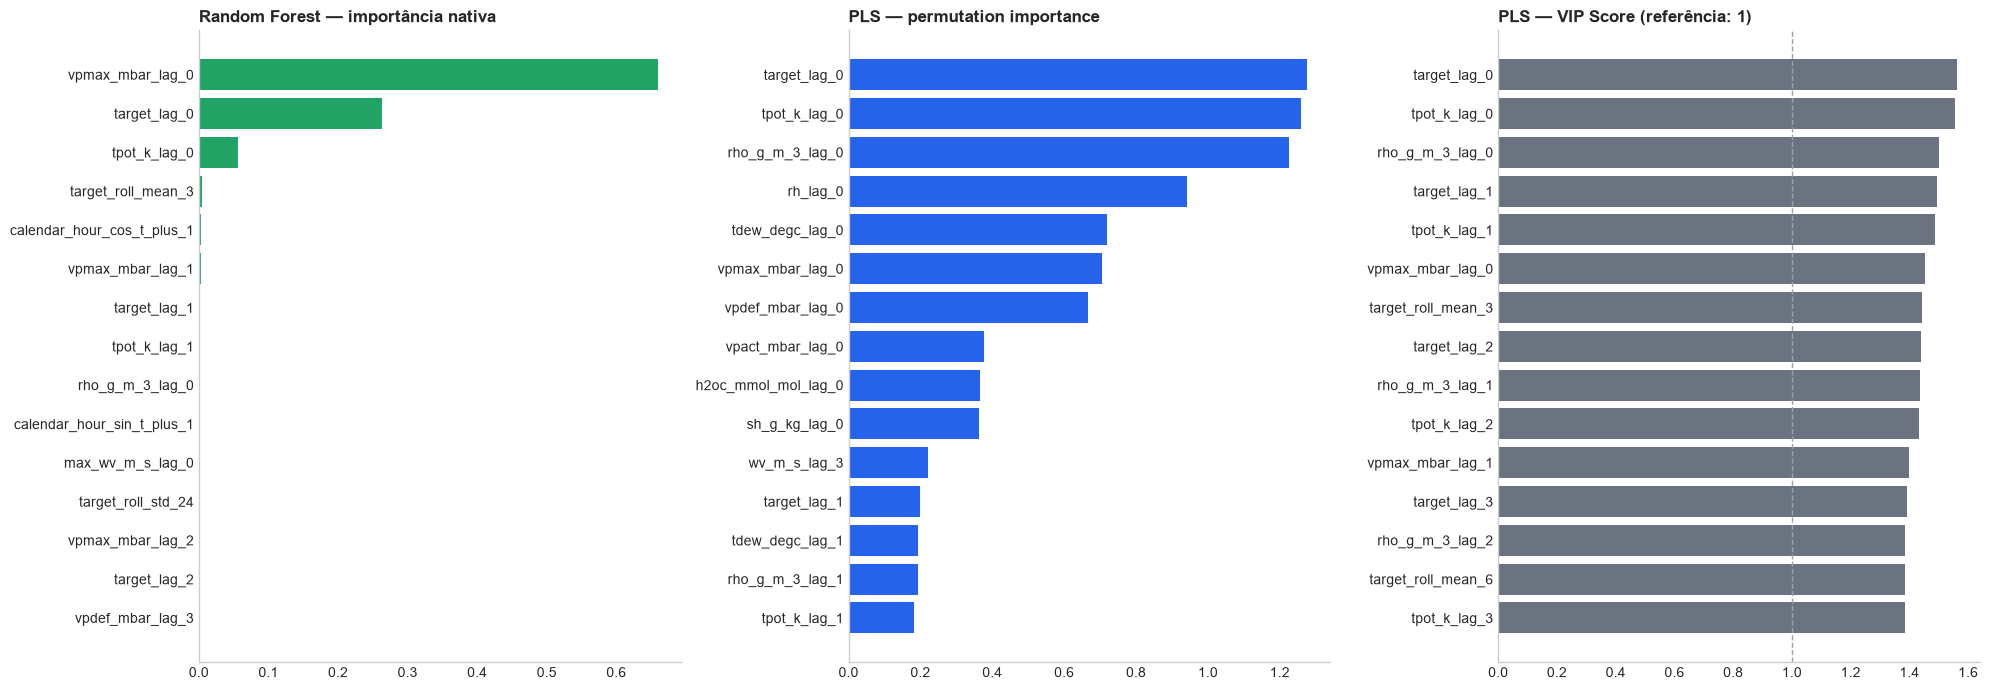

In [ ]:
# 18. Visualização da importância de features
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

rf_top = rf_importance.head(15).sort_values('importance_native')
axes[0].barh(rf_top['feature'], rf_top['importance_native'], color='#21A366')
axes[0].set_title('Random Forest — importância nativa', loc='left')

pls_perm_top = pls_importance.head(15).sort_values('permutation_importance_mean')
axes[1].barh(pls_perm_top['feature'], pls_perm_top['permutation_importance_mean'], color='#2563EB')
axes[1].set_title('PLS — permutation importance', loc='left')

pls_vip_top = pls_importance.sort_values('vip_score', ascending=False).head(15).sort_values('vip_score')
axes[2].barh(pls_vip_top['feature'], pls_vip_top['vip_score'], color='#6B7280')
axes[2].axvline(1.0, color='#9CA3AF', linewidth=1, linestyle='--')
axes[2].set_title('PLS — VIP Score (referência: 1)', loc='left')

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'feature_importance_comparison.png', dpi=140, bbox_inches='tight')
plt.show()


## 13. Estudo técnico do modelo de especialização: PLS Regression

### Funcionamento e intuição

O PLS constrói componentes latentes como combinações lineares das features de `X` que maximizam a covariância com o alvo `Y`. Diferentemente da PCA, que procura apenas explicar a variância de `X`, o PLS usa também a informação do alvo para orientar os componentes. A regressão final ocorre no espaço reduzido.

Isso é útil neste problema porque lags da temperatura, umidade, pressão e variáveis derivadas são correlacionados. Em vez de estimar um coeficiente instável para cada coluna colinear, o PLS concentra a informação em poucos componentes supervisionados.

### Hipóteses, vantagens e limitações

- **Hipóteses:** relação predominantemente aditiva/linear no espaço latente; as features foram construídas de modo causal; a escala das variáveis é relevante e por isso `scale=True` foi usado.
- **Vantagens:** lida bem com multicolinearidade, reduz dimensionalidade e oferece coeficientes, VIP e importância por permutação.
- **Limitações:** não captura não linearidades tão diretamente quanto florestas; o número de componentes precisa ser escolhido; VIP não é causalidade; componentes demais podem ajustar ruído.
- **Preparação:** lags e janelas precisam ser calculados respeitando o tempo, e o escalonamento deve ser aprendido somente no treino de cada ajuste.

### Hiperparâmetros

O principal hiperparâmetro é `n_components`. Poucos componentes podem produzir subajuste; muitos podem reintroduzir colinearidade e ruído. `scale=True` padroniza `X` e `Y` dentro do ajuste, `tol` controla a convergência e `max_iter` limita as iterações do algoritmo NIPALS.

### Interpretação

- `VIP > 1` é uma regra prática para destacar variáveis relevantes no espaço latente;
- o coeficiente indica direção no modelo, mas sua magnitude deve ser interpretada junto da padronização e das unidades;
- a permutation importance mede a perda de desempenho quando a coluna é embaralhada no teste;
- features do mesmo fenômeno podem dividir sua importância por serem correlacionadas.

A conclusão final deve combinar o MAE fora da amostra com esses três sinais, nunca escolher uma feature apenas por um ranking isolado.


In [ ]:
# 19. Relatório específico do PLS: componentes, VIP e tabela de hiperparâmetros
pls_component_summary = pd.DataFrame({
    'componente': np.arange(1, pls_final.x_scores_.shape[1] + 1),
    'variancia_x_dos_scores': np.var(pls_final.x_scores_, axis=0),
    'contribuicao_y_usada_no_vip': np.sum(pls_final.x_scores_ ** 2, axis=0) * np.sum(pls_final.y_loadings_ ** 2, axis=0),
})
pls_component_summary['proporcao_contribuicao_y'] = (
    pls_component_summary['contribuicao_y_usada_no_vip']
    / pls_component_summary['contribuicao_y_usada_no_vip'].sum()
)
pls_component_summary.to_csv(OUTPUT_DIR / 'pls_component_summary.csv', index=False)

display(Markdown(
    f"**PLS selecionado:** `{best_pls}`. "
    f"Foram usados {best_pls['n_components']} componentes latentes e "
    f"{X_train.shape[1]} features de entrada."
))
display(pls_component_summary)


**PLS selecionado:** `{'n_components': 16, 'scale': True, 'max_iter': 500, 'tol': 1e-06}`. Foram usados 16 componentes latentes e 166 features de entrada.

,componente,variancia_x_dos_scores,contribuicao_y_usada_no_vip,proporcao_contribuicao_y
0,1,75.047291,49812.179790,0.907874
1,2,9.022881,2141.496561,0.039031
2,3,5.218318,1358.891501,0.024767
3,4,2.923114,550.131621,0.010027
4,5,4.643670,377.607957,0.006882
5,6,3.143822,132.727029,0.002419
6,7,1.393723,120.215727,0.002191
7,8,2.860718,71.380554,0.001301
8,9,1.550723,75.365039,0.001374
9,10,2.276558,52.034373,0.000948


## 14. Síntese, reprodutibilidade e registro de demandas

Os arquivos exportados na pasta de resultados incluem:

- diagnósticos da base, dicionário de variáveis e dicionário de features;
- componentes e resumo da STL;
- tabelas de busca de hiperparâmetros;
- previsões longas e comparação de MAE;
- tabela de vitórias/posição, resíduos e Ljung–Box;
- coeficientes SARIMAX;
- importâncias do Random Forest e do PLS;
- parâmetros do Holt–Winters, tempos de execução e resumo final.

O registro diário abaixo é um **modelo para preenchimento pelo grupo**. Não foram inventados nomes, datas ou responsabilidades dos integrantes.


In [ ]:
# 20. Resumo final e arquivos de apoio
selected_hyperparameters = pd.DataFrame([
    {'model': 'SARIMAX', 'selected_params': params_to_json(best_sarimax)},
    {'model': 'Holt-Winters', 'selected_params': params_to_json(best_hw)},
    {'model': 'Random Forest', 'selected_params': params_to_json(best_rf)},
    {'model': 'PLS Regression', 'selected_params': params_to_json(best_pls)},
])
selected_hyperparameters.to_csv(OUTPUT_DIR / 'selected_hyperparameters.csv', index=False)

runtime_table = pd.DataFrame(runtime_records)
runtime_table.to_csv(OUTPUT_DIR / 'runtime_table.csv', index=False)

demand_log_template = pd.DataFrame(columns=[
    'data', 'integrante', 'demanda_realizada', 'entrega_ou_evidencia',
    'carga_de_trabalho', 'complexidade', 'status',
])
demand_log_template.to_csv(OUTPUT_DIR / 'registro_demandas_template.csv', index=False)

summary = {
    'status': 'ok',
    'base': str(CSV_PATH),
    'dataset_filename': DATASET_FILENAME,
    'dataset_sha256': DATASET_SHA256,
    'base_count_received': 1,
    'base_count_required_by_pdf': 5,
    'note_about_scope': 'A Jena Climate completa foi processada; as outras quatro bases previstas no PDF não estão disponíveis neste pacote e não tiveram resultados inventados.',
    'frequency': FREQ,
    'aggregation': diagnostics['aggregation_rule'],
    'target': TARGET,
    'horizon_hours': HORIZON,
    'random_state': RANDOM_STATE,
    'train_fraction': TRAIN_FRACTION,
    'test_fraction': TEST_FRACTION,
    'hourly_observations': len(hourly),
    'complete_hourly_bins_before_regularization': diagnostics['rows_after_aggregation'],
    'regularized_hourly_positions': diagnostics['rows_after_regularization'],
    'supervised_observations': len(X),
    'train_observations': len(X_train),
    'test_observations': len(X_test),
    'split_origin': split_origin,
    'split_timestamp': hourly.index[split_origin],
    'seasonal_strength': seasonal_strength,
    'best_sarimax': best_sarimax,
    'best_holt_winters': best_hw,
    'best_random_forest': best_rf,
    'best_pls': best_pls,
    'refit_every_hours_tabular': REFIT_EVERY,
    'max_train_rows_tabular': MAX_TRAIN_ROWS,
    'mae_table': mae_table.to_dict(orient='records'),
    'ljung_box': ljung_table.to_dict(orient='records'),
    'future_observed_exog_used': False,
    'output_dir': str(OUTPUT_DIR.resolve()),
}
save_json('final_summary.json', summary)

print('=== RESULTADO FINAL DA BASE JENA CLIMATE ===')
display(mae_table)
print(f'Melhor modelo nesta base: {mae_table.iloc[0]["model"]}')
print(f'MAE vencedor: {mae_table.iloc[0]["MAE"]:.5f} °C')
print(f'Resultados salvos em: {OUTPUT_DIR.resolve()}')
print('O notebook pode ser reexecutado com o mesmo CSV, random_state=42 e protocolo temporal 80/20.')


=== RESULTADO FINAL DA BASE JENA CLIMATE ===


,model,MAE,bias,residual_std,n,rank,win,mean_rank_current_base
0,Holt-Winters,0.483222,-0.000060,0.714909,13782,1,1,1
1,Random Forest,0.570118,0.003197,0.876546,13782,2,0,2
2,SARIMAX,0.801746,-0.024803,9.396521,13782,3,0,3
3,PLS Regression,1.007823,-0.026639,13.784195,13782,4,0,4


Melhor modelo nesta base: Holt-Winters
MAE vencedor: 0.48322 °C
Resultados salvos em: /Users/guilherme.nacarelli/Documents/trabalho_daniel/resultados_grupo5_jena_horario
O notebook pode ser reexecutado com o mesmo CSV, random_state=42 e protocolo temporal 80/20.


## 15. Conclusões e referências para o relatório

Ao redigir o relatório técnico, a conclusão deve responder:

1. qual modelo teve menor MAE na Jena Climate;
2. se o ranking se mantém ao longo dos blocos do walk-forward;
3. se os resíduos ainda apresentam padrão diário ou semanal;
4. quais features externas aparecem como relevantes e se estavam disponíveis na origem;
5. em que medida a multicolinearidade favoreceu ou prejudicou o PLS;
6. quais limitações permanecem por as outras quatro bases previstas no enunciado não estarem disponíveis neste pacote.

### Referências

- Enunciado da atividade: **TRABALHO — SÉRIES TEMPORAIS: Modelagem Comparativa de Séries Temporais com Variáveis Externas**.
- Max Planck Institute for Biogeochemistry. **Jena Climate Dataset**.
- Cleveland et al. (1990). **STL: A Seasonal-Trend Decomposition Procedure Based on Loess**.
- Hyndman, R. J.; Athanasopoulos, G. **Forecasting: Principles and Practice** — validação temporal e métricas de previsão.
- Documentação do `statsmodels`: `STL`, `SARIMAX` e `ExponentialSmoothing`.
- Documentação do `scikit-learn`: `RandomForestRegressor`, `PLSRegression` e `permutation_importance`.

> Antes da entrega pela Plataforma Odete, preencher o registro de demandas, conferir os nomes dos integrantes e, caso existam as demais quatro bases, executar o mesmo protocolo para cada uma e consolidar os rankings por base sem somar MAEs entre escalas diferentes.
